# VNS-Only – Toggle Missed-Order Penalty + ROP
With **toggle** Version `USE_MISSED_ORDER_PENALTY` and Breakdown Cost

In [12]:
# -*- coding: utf-8 -*-
import math, random, time
from typing import Dict, Tuple, List
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RANDOM_SEED = 123
POP_SIZE = 120
GENERATIONS = 300

# Toggle penalti
USE_PENALTIES = True               # penalti kapasitas, Q<=D, SS target, budget
USE_MISSED_ORDER_PENALTY = True     # penalti BIG_COST saat D>0 & Q=0

# GA params
IPOX_N_MIN_FRAC = 0.05
IPOX_N_MAX_FRAC = 0.25
PC_BASE    = 0.75
C_INTERVAL = 0.20
PO_BASE    = 0.10
O_INTERVAL = 0.15
SWAP_COUNT = 1

# VNS params (dipakai di Hybrid/VNS-only)
K_MAX = 2
LS_MAX_ITERS = 5
VNS_SAMPLE_SIZE = 40
SHAKE_INTENSITY = [1,2,3,4,5]
DELTA_SCALE = [0.05,0.10,0.15,0.20,0.25]
N_STARTS = 10

# Penalti (aktif bila USE_PENALTIES=True)
PENALTY_SS_TARGET = 1e9
PENALTY_CAPACITY  = 1e9
PENALTY_BUDGET    = 1e9
PENALTY_Q_LEQ_D   = 1e9

# Fill rate
TARGET_FILL = 0.80
PENALTY_FILL = 1e9

# Statistik
Z_SERVICE = 1.28
LEAD_TIME_UNIT   = 'days'   # 'days' atau 'months'
USE_POISSON_SIGMA = True
SIGMA_OVERRIDE: Dict[int, float] = {}

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
plt.style.use('seaborn-v0_8')


## Load Data & Inisialisasi

In [13]:
# ========= Load Data =========
#-- Helper Functions --#
def _to_number(x: str) -> float:
    if pd.isna(x): return np.nan
    if isinstance(x, (int,float)): return float(x)
    x = str(x).replace('"','').replace("'",'').replace(',','').strip()
    if x=='': return np.nan
    return float(x)

# Cost Data
raw = pd.read_csv('Cost.csv', dtype=str)
for c in [c for c in raw.columns if c not in ['Material','Material Description']]:
    raw[c] = raw[c].apply(_to_number)

# Distribution Centers
M = raw.shape[0]
DCs = []
for j in range(1,10):
    if all(f in raw.columns for f in [f'hi{j}',f'Ki{j}',f'Di{j}',f'Ci{j}']):
        DCs.append(j)
N = len(DCs); assert N>0, 'Kolom DC (hi*/Ki*/Di*/Ci*) tidak lengkap'

# Customers
customers = [k for k in range(1,101) if f'di{k}' in raw.columns]
O = len(customers)
assert 'Ii' in raw.columns, 'Kolom Ii tidak ditemukan di Cost.csv'

# Matriks Parameters per DC (h_ij, K_ij, D_ij, C_ij)
h    = np.zeros((M,N))
K    = np.zeros((M,N))
D_dc = np.zeros((M,N))
C    = np.zeros((M,N))
for i in range(M):
    for jj,j in enumerate(DCs):
        h[i,jj]    = 0.0 if pd.isna(raw.loc[i, f'hi{j}']) else raw.loc[i, f'hi{j}']
        K[i,jj]    = 0.0 if pd.isna(raw.loc[i, f'Ki{j}']) else raw.loc[i, f'Ki{j}']
        D_dc[i,jj] = 0.0 if pd.isna(raw.loc[i, f'Di{j}']) else raw.loc[i, f'Di{j}']
        C[i,jj]    = 0.0 if pd.isna(raw.loc[i, f'Ci{j}']) else raw.loc[i, f'Ci{j}']

# Demand per customer (d_ik)
D_cust = np.zeros((M,O))
for i in range(M):
    for kk,k in enumerate(customers):
        col = f'di{k}'
        D_cust[i,kk] = 0.0 if col not in raw.columns or pd.isna(raw.loc[i, col]) else raw.loc[i, col]

D_tot_cust = D_cust.sum(axis=1)
D_tot_dc   = D_dc.sum(axis=1)
D_tot      = np.where(D_tot_cust>0, D_tot_cust, D_tot_dc)

# p_ik (penalty per-customer) atau fallback
pik_cols = [f'pik{k}' for k in customers if f'pik{k}' in raw.columns]
if len(pik_cols) == O:
    p_ik = np.zeros((M,O))
    for i in range(M):
        for kk,k in enumerate(customers):
            p_ik[i,kk] = 0.0 if pd.isna(raw.loc[i, f'pik{k}']) else raw.loc[i, f'pik{k}']
else:
    pi_cols = [f'pi{j}' for j in DCs if f'pi{j}' in raw.columns]
    p_i = np.zeros(M)
    for i in range(M):
        if pi_cols:
            vals=[raw.loc[i,c] for c in pi_cols]
            p=np.nanmean(vals)
            if np.isnan(p): p=0.003*np.nanmean(K[i])
        else:
            p=0.003*np.nanmean(K[i])
        p_i[i]=0.0 if np.isnan(p) else p
    p_ik = np.repeat(p_i.reshape(-1,1), O, axis=1)

# Budget per part
I_i = raw['Ii'].fillna(0.0).astype(float).values

# SOH per part (initial inventory)
assert 'SOH' in raw.columns, 'Kolom SOH tidak ditemukan di Cost.csv'
SOH_i = raw['SOH'].fillna(0.0).astype(float).values

# Lead time & sigma
lt_df = pd.read_csv('Act LT.csv')
L_samples = []
for i in range(M):
    col = f'Part_{i+1}'
    vals = pd.to_numeric(lt_df[col], errors='coerce').dropna().values
    L_samples.append(np.mean(vals) if vals.size>0 else 0.0)
L_samples = np.array(L_samples)
L_i = L_samples/30.0 if LEAD_TIME_UNIT=='days' else L_samples.copy()

mu_i = D_tot.astype(float)
if USE_POISSON_SIGMA:
    sigma_i = np.sqrt(np.maximum(mu_i, 0.0))
else:
    sigma_i = np.array([SIGMA_OVERRIDE.get(i+1, np.sqrt(max(mu_i[i], 0.0))) for i in range(M)], dtype=float)

# ========= Safety Stock Calculation =========
SS_target = Z_SERVICE * sigma_i * np.sqrt(np.maximum(L_i, 0.0))

# EOQ init Calculation
K_bar = np.where(np.isnan(K).all(axis=1), 0.0, np.nanmean(K, axis=1))
h_bar = np.where(np.isnan(h).all(axis=1), 0.0, np.nanmean(h, axis=1))
D_for_eoq = np.where(D_tot_dc > 0, D_tot_dc, D_tot)
EOQ_i = np.sqrt(np.maximum(2.0 * np.maximum(D_for_eoq, 0.0) * np.maximum(K_bar, 1e-9) / np.maximum(h_bar, 1e-9), 0.0))

# Inisialisasi Q0 & SS0 ========= Initial Solution =========
D_prop = D_dc / np.maximum(D_dc.sum(axis=1, keepdims=True), 1e-9)
SS_prop = np.ones_like(D_prop) / N
Q0  = np.floor((EOQ_i.reshape(-1,1) * D_prop)).astype(int)
SS0 = np.ceil((SS_target.reshape(-1,1) * SS_prop)).astype(int)

# ========= GA Encoding/Decoding =========
# Batas variabel
# Optional: map each customer to a DC index (0..N-1). If None, customers are assigned round-robin.
# Provide a list of length O to override, e.g. CUSTOMER_TO_DC = [0,0,1,1,2,...]
CUSTOMER_TO_DC = None
if CUSTOMER_TO_DC is None:
    cust_to_dc_idx = np.arange(O) % N
else:
    cust_to_dc_idx = np.array(CUSTOMER_TO_DC, dtype=int)
    assert cust_to_dc_idx.shape[0] == O, 'CUSTOMER_TO_DC must have length O'
# Compute demand (per material) assigned to each DC from customers' demands
D_cust_assigned = np.zeros((M, N))
for j in range(N):
    mask = (cust_to_dc_idx == j)
    if mask.any():
        D_cust_assigned[:, j] = D_cust[:, mask].sum(axis=1)
# Upper bounds: ensure Q_ij ≤ D_dc, ≤ capacity C, and ≤ demand of customers assigned to that DC
Q_lb = np.zeros((M,N), dtype=int)
Q_ub = np.floor(np.minimum(np.minimum(D_dc, C), D_cust_assigned)).astype(int)
# Enforce per-DC safety stock target as a lower bound for SS (SS_ij ≥ SS_target_i)
SS_lb = np.ceil(np.repeat(SS_target.reshape(-1,1), N, axis=1)).astype(int)
SS_ub = np.floor(C).astype(int)

VAR_COUNT = 2*M*N

#========= Packing / Unpacking =========
def pack(Q: np.ndarray, SS: np.ndarray) -> np.ndarray:
    return np.concatenate([Q.reshape(-1), SS.reshape(-1)])

def unpack(chrom: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    Q_flat  = chrom[: M*N]
    SS_flat = chrom[M*N : 2*M*N]
    return Q_flat.reshape(M, N), SS_flat.reshape(M, N)

print(f'Jumlah part (M): {M}, jumlah DC (N): {N}, jumlah customer (O): {O}')


Jumlah part (M): 10, jumlah DC (N): 3, jumlah customer (O): 20


## Objective & Utilities (dengan toggle penalti missed-order)

In [14]:
# ========= FILL-RATE TARGETING (soft penalty + budget-aware SS floor) =========
# Goal: drive achieved fill rate to >= TARGET_FILL (e.g. 0.90) AND make the
# deterministic VNS fill rate match its Monte-Carlo evaluation.
#
# Mechanisms:
#   (1) SS floor : set the safety-stock lower bound so each part can cover
#                  TARGET_FILL of its period demand, allocating SS to the
#                  lowest-K (cheapest-to-budget) DC first, respecting capacity
#                  (Q+SS<=C) and the budget constraint ((Q+SS)*K<=I_i). Guarantees
#                  ~TARGET_FILL regardless of Q and still meets sum_j SS_ij >= SS_target_i.
#   (2) soft fill penalty added to compute_cost so the GA keeps fill >= TARGET_FILL.
#   (3) SOH consistency: supply counts on-hand SOH_i ONCE per part (S_i = sum_j(Q+SS) + SOH_i),
#       matching compute_mc_cost so the deterministic and Monte-Carlo fill rates agree.

# ---- (1) budget- & capacity-aware safety-stock coverage floor ----
def _coverage_ss_floor(target):
    # Per-cell SS lower bound that (a) covers ~target of period demand assuming Q=0
    # (worst case, so it holds for any Q), (b) concentrates SS on the lowest-K DC so
    # the budget (Q+SS)*K <= I_i stays satisfied, (c) reserves capacity for Q (Q+SS<=C),
    # and (d) is at least the classical safety-stock target per part.
    # NOTE: SOH counted ONCE (matches the supply definition S_i = sum_j(Q+SS) + SOH_i).
    SSf = np.zeros((M, N), dtype=int)
    for i in range(M):
        D_i = float(np.sum(D_cust[i]))
        cover_need = (target * D_i - float(SOH_i[i])) if D_i > 0 else 0.0
        need_units = max(cover_need, float(np.ceil(SS_target[i])))
        cap_room = np.maximum(0, SS_ub[i] - Q_ub[i])              # keep Q+SS <= C
        bud_left = float(I_i[i]) - float(np.sum(Q_ub[i] * K[i]))  # reserve budget for Q at its upper bound
        rem = max(0.0, need_units)
        for j in np.argsort(K[i]):                               # cheapest-budget DC first
            if rem <= 0:
                break
            kij = max(float(K[i, j]), 1e-9)
            take = min(rem, float(cap_room[j]), (bud_left / kij if bud_left > 0 else 0.0))
            take = int(max(0, np.floor(take)))
            SSf[i, j] = take
            rem -= take
            bud_left -= take * kij
    return SSf

# Replace the (scattered, sometimes budget-infeasible) per-DC SS_target floor with the
# budget/capacity-aware coverage floor. Per-part total still satisfies SS_target.
SS_cover_lb = _coverage_ss_floor(TARGET_FILL)
SS_lb = np.minimum(SS_cover_lb, SS_ub).astype(int)
SS0   = np.clip(SS0, SS_lb, SS_ub)            # warm-start initial SS respects the new floor

print("Fill-rate targeting enabled:")
print(f"  TARGET_FILL = {TARGET_FILL}, PENALTY_FILL = {PENALTY_FILL:.0e}")
print("  SS coverage floor per part (sum over DCs):", SS_lb.sum(axis=1))
print("  SS_lb total = %d, SS_ub total = %d" % (int(SS_lb.sum()), int(SS_ub.sum())))

# ========= Utilities & Objective =========
#Supply Constraint: Q_ij + SS_ij <= C_ij)
def clamp_to_bounds(Q: np.ndarray, SS: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    Q  = np.minimum(np.maximum(Q,  Q_lb), Q_ub)
    SS = np.minimum(np.maximum(SS, SS_lb), SS_ub)
    # enforce Q+SS ≤ C: kurangi SS dahulu, lalu Q
    excess = np.maximum(Q + SS - C, 0)
    reduce_ss = np.minimum(SS, excess)
    SS = SS - reduce_ss
    excess = np.maximum(Q + SS - C, 0)
    reduce_q = np.minimum(Q, excess)
    Q = Q - reduce_q
    return Q, SS

# ---- (2)+(3) redefine objective: soft fill penalty, missed-order guard, SOH counted once ----
def compute_cost(Q: np.ndarray, SS: np.ndarray):
    # Holding
    holding = float(np.sum(h * (Q/2.0 + SS)))

    # Ordering murni + penalti missed-order dipisah
    ordering = 0.0
    order_miss_penalty = 0.0
    BIG_COST = 1e12
    for i in range(M):
        for j in range(N):
            Dij = D_dc[i, j]
            Qij = max(Q[i, j], 0)
            if Dij <= 0:
                continue
            if Qij <= 0:
                # Only penalize a missing order where ordering is actually feasible
                # (Q_ub>0). Cells with Q_ub==0 (no capacity/assigned demand) are
                # structurally impossible to order and must be served from SS/SOH.
                if USE_MISSED_ORDER_PENALTY and Q_ub[i, j] > 0:
                    order_miss_penalty += BIG_COST
            else:
                ordering += K[i, j] * (Dij / Qij)

    # Shortage per-customer
    shortage_cost = 0.0
    shortage_volume = 0.0
    total_demand = 0.0
    for i in range(M):
        S_i     = float(np.sum(Q[i] + SS[i]) + SOH_i[i])   # SOH counted ONCE (matches MC)
        D_i_tot = float(np.sum(D_cust[i]))
        if D_i_tot <= 0.0:
            continue
        B_i_tot = max(0.0, D_i_tot - S_i)
        shortage_volume += B_i_tot
        total_demand += D_i_tot
        if B_i_tot <= 1e-12:
            continue
        alloc = (D_cust[i] / D_i_tot) * B_i_tot
        shortage_cost += float(np.sum(p_ik[i] * alloc))

    # Supply / Budget Constraint: sum((Q_ij + SS_ij) * K_i) <= I_i for each material i
    pen_budget = 0.0
    BIG_BUDGET_PENALTY = 1e12
    for i in range(M):
        total_inv_cost_i = float(np.sum((Q[i] + SS[i]) * K[i]))
        if total_inv_cost_i > I_i[i]:
            excess_budget = total_inv_cost_i - I_i[i]
            pen_budget += BIG_BUDGET_PENALTY * (excess_budget / max(I_i[i], 1.0))

    # Penalti opsional lainnya
    pen_cap = pen_qleqd = pen_ss = 0.0
    if USE_PENALTIES:
        cap_violation  = np.maximum(Q + SS - C, 0)
        pen_cap        = (cap_violation * PENALTY_CAPACITY).sum()

        q_leq_d_violation = np.maximum(Q - D_cust_assigned, 0)
        pen_qleqd         = (q_leq_d_violation * PENALTY_Q_LEQ_D).sum()

        ss_deficit = np.maximum(SS_target - SS.sum(axis=1), 0.0)
        pen_ss     = float(np.sum(ss_deficit) * PENALTY_SS_TARGET)

    # Fill rate
    fill_rate     = 1 - (shortage_volume / total_demand) if total_demand > 0 else 1.0

    # Soft service-level penalty: push the optimizer to keep fill_rate >= TARGET_FILL
    pen_fill = PENALTY_FILL * max(0.0, TARGET_FILL - fill_rate)

    total_basic   = holding + ordering + shortage_cost
    total_penalty = order_miss_penalty + pen_cap + pen_qleqd + pen_ss + pen_budget + pen_fill
    total_all     = total_basic + total_penalty

    breakdown = {
        'holding'           : holding,
        'ordering'          : ordering,
        'shortage'          : shortage_cost,
        'order_miss_penalty': order_miss_penalty,
        'pen_cap'           : pen_cap,
        'pen_q_leq_d'       : pen_qleqd,
        'pen_ss'            : pen_ss,
        'pen_budget'        : pen_budget,
        'pen_fill'          : pen_fill,
        'total_basic'       : total_basic,
        'total_penalty'     : total_penalty,
        'total'             : total_all,
        'fill_rate'         : fill_rate,
    }
    return total_all, breakdown

# ROP helper
def compute_rop(Q: np.ndarray, SS: np.ndarray) -> np.ndarray:
    mu_lt = D_dc * L_i.reshape(-1,1)
    return mu_lt + SS

Fill-rate targeting enabled:
  TARGET_FILL = 0.8, PENALTY_FILL = 1e+09
  SS coverage floor per part (sum over DCs): [12682   161   568   637    12    22   168  2188   122   155]
  SS_lb total = 16715, SS_ub total = 90690


## VNS-Only Runner

Start 01 | cost awal: 659,593,750,424.97
           | cost akhir: 200,542,392.24
Start 02 | cost awal: 1,655,567,501,442.51
           | cost akhir: 212,434,223.45
Start 03 | cost awal: 1,140,863,321,838.54
           | cost akhir: 213,890,656.15
Start 04 | cost awal: 1,415,047,692,836.67
           | cost akhir: 225,157,614.50
Start 05 | cost awal: 859,985,101,463.14
           | cost akhir: 224,922,228.62
Start 06 | cost awal: 2,884,157,887,809.30
           | cost akhir: 238,712,258.41
Start 07 | cost awal: 512,793,149,468.95
           | cost akhir: 225,146,501.21
Start 08 | cost awal: 607,218,387,794.45
           | cost akhir: 223,819,649.54
Start 09 | cost awal: 288,322,977,161.62
           | cost akhir: 216,256,392.99
Start 10 | cost awal: 2,384,951,229,882.81
           | cost akhir: 224,763,168.90

=== HASIL TERBAIK (VNS) ===
Convergence Time (sec): 0.4165
  - holding             : 99,453,418.03
  - ordering (murni)    : 89,723,552.30
  - shortage            : 12,705,293.38


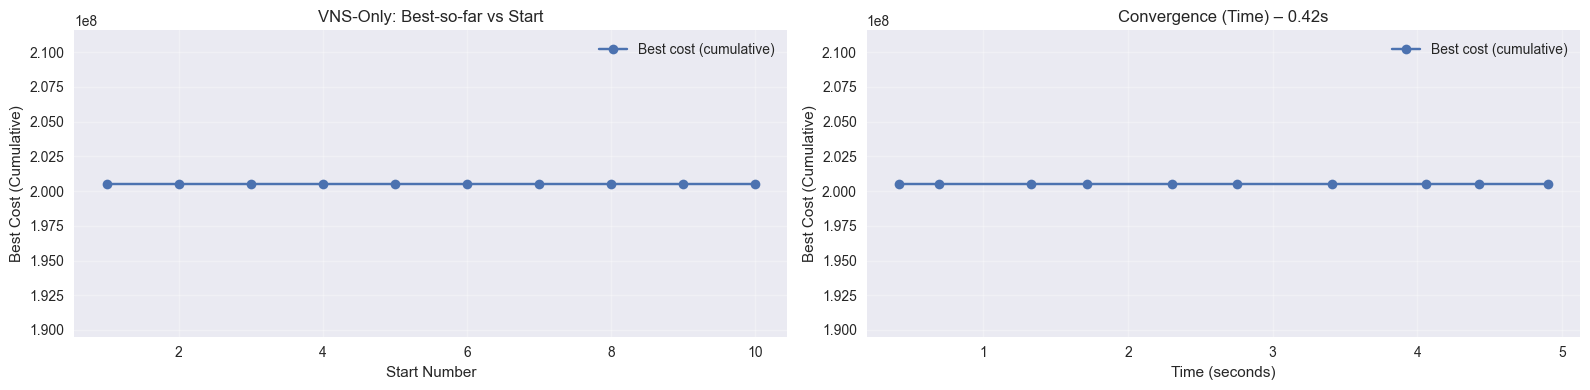

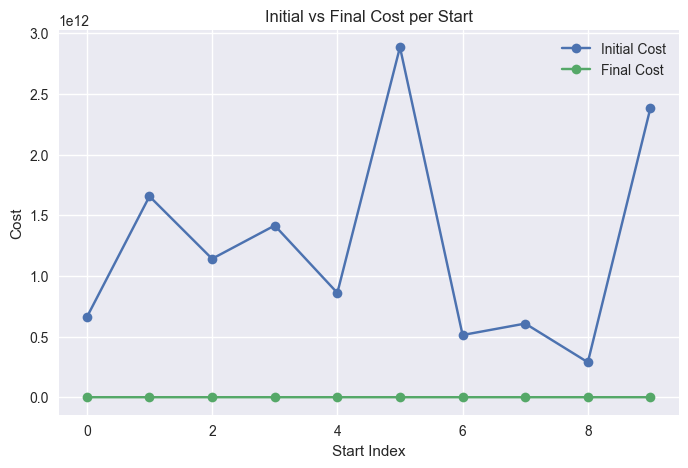

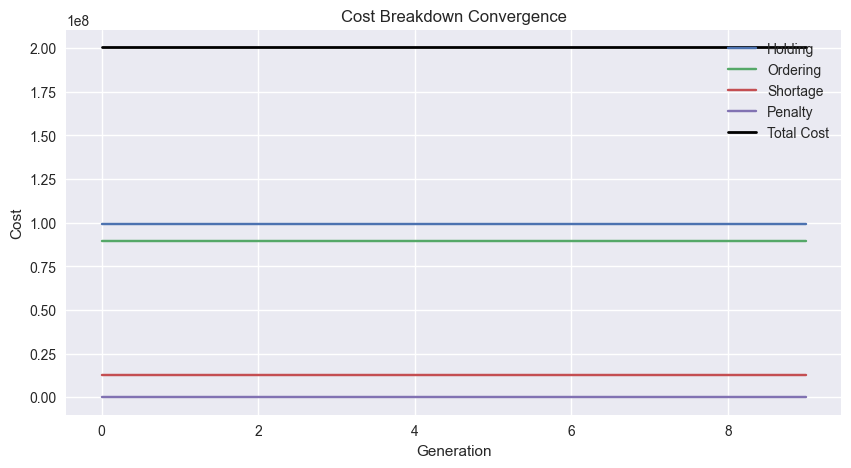

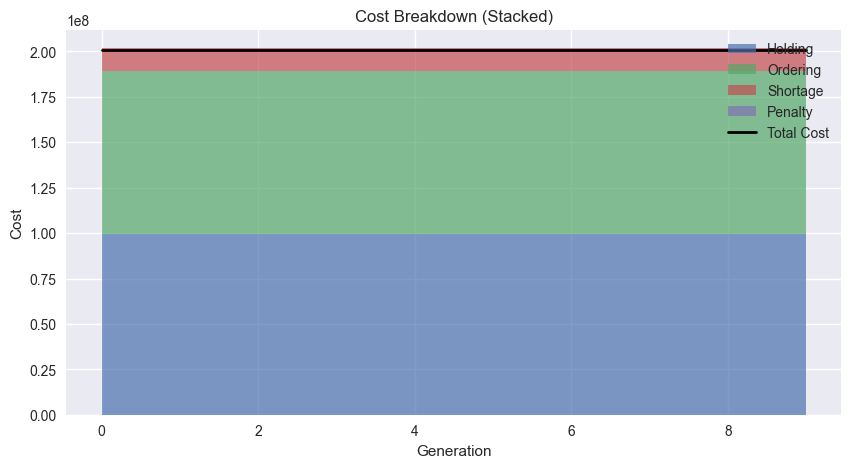

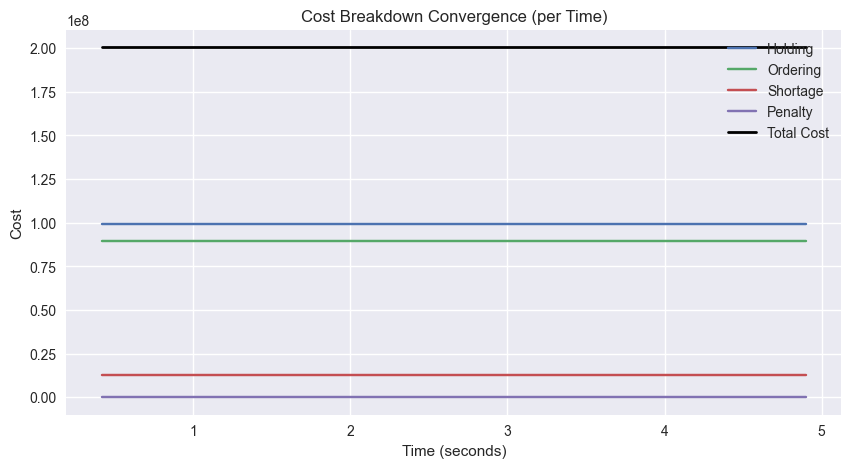

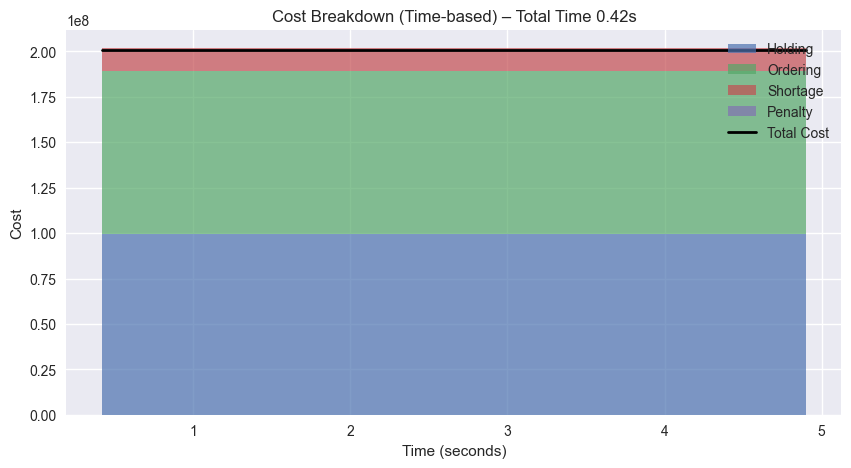

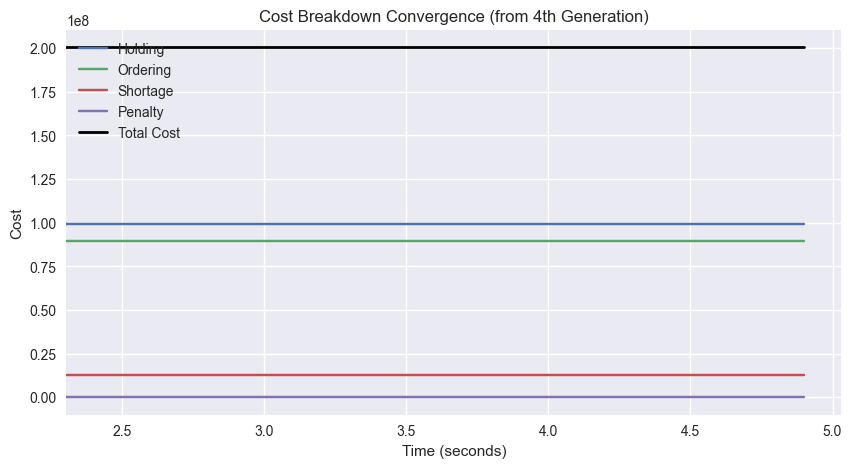

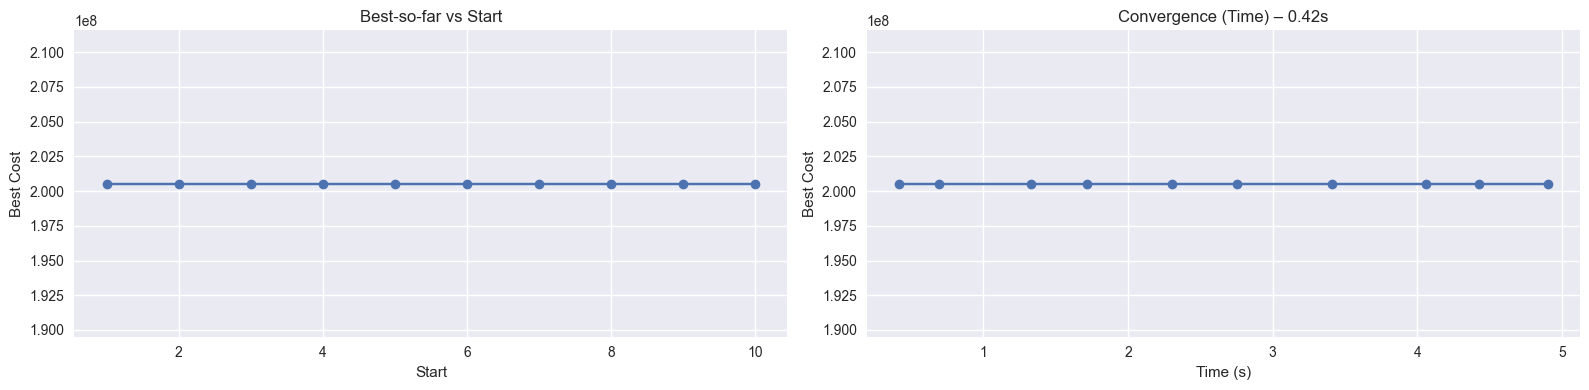

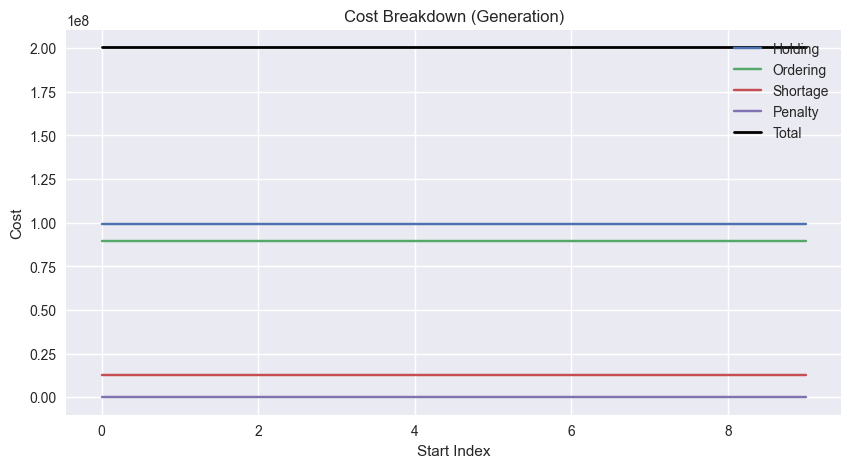

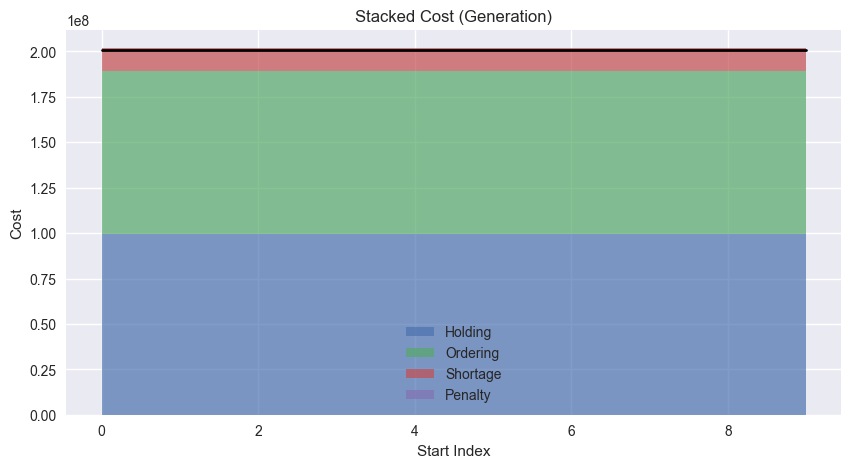

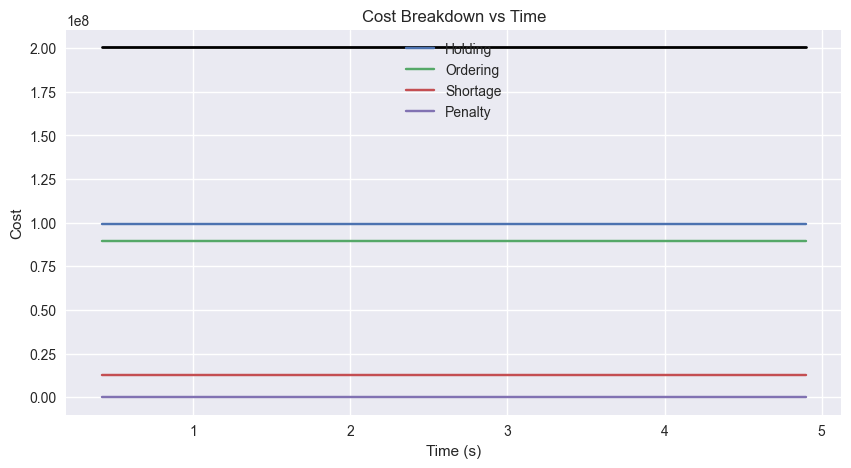

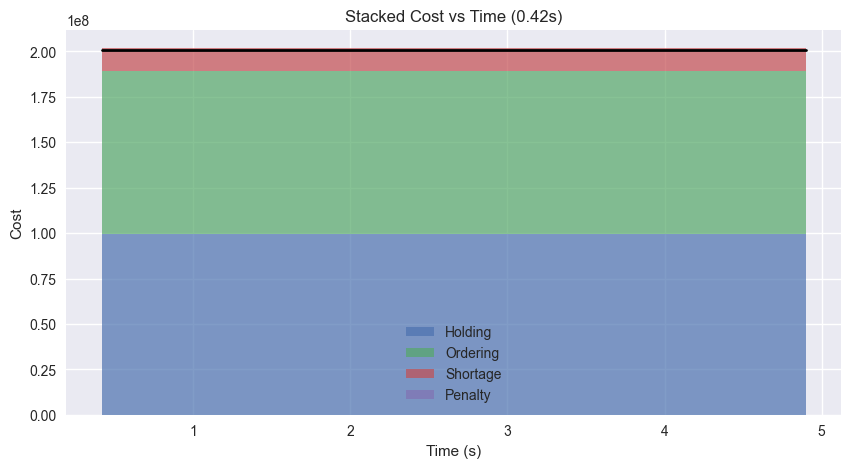

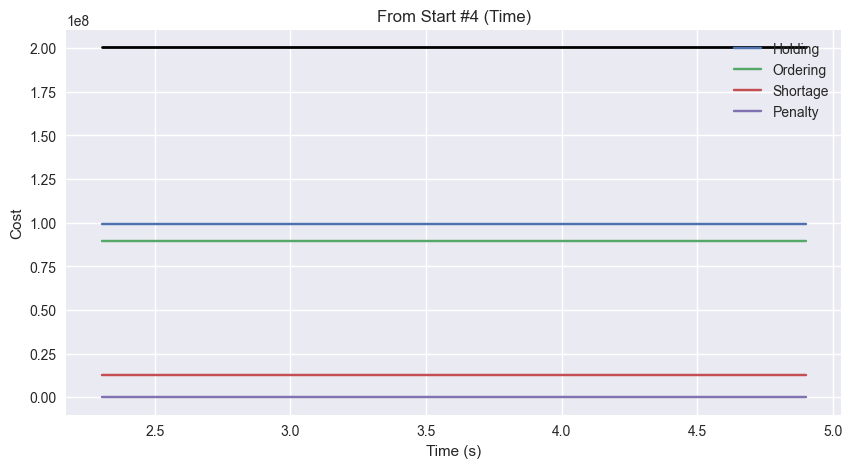

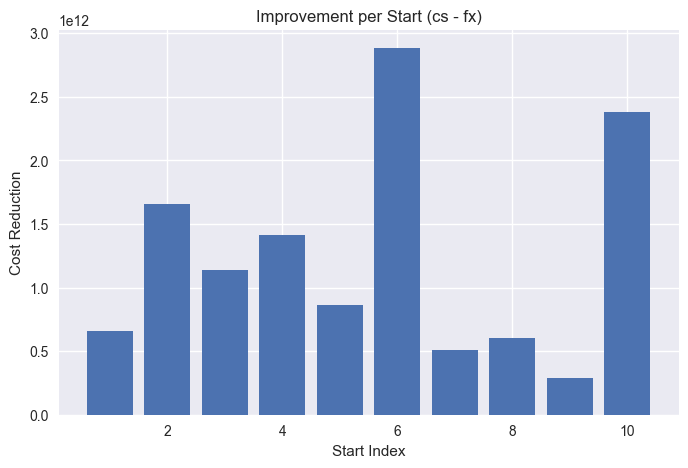

Disimpan: VNS_convergence_history_20260615_081632.csv
Disimpan: vns_best_solution_4.csv


In [15]:
#VNS components: shake (diversification) + local search (intensification)
def init_individual() -> np.ndarray:
    Q = Q0.copy()
    SS = SS0.copy()
    for i in range(M):
        for j in range(N):
            qmax = int(Q_ub[i, j])
            smax = int(SS_ub[i, j])
            if qmax > 0:
                step_q = max(1, qmax // 10)
                Q[i, j] = max(0, int(Q[i, j] + np.random.randint(-step_q, step_q + 1)))
            if smax > 0:
                step_s = max(1, smax // 10)
                SS[i, j] = max(0, int(SS[i, j] + np.random.randint(-step_s, step_s + 1)))
    Q, SS = clamp_to_bounds(Q, SS)
    return pack(Q, SS)

def shake(chrom: np.ndarray, k: int) -> np.ndarray:
    Q, SS = unpack(chrom); Q = Q.copy(); SS = SS.copy()
    m = SHAKE_INTENSITY[min(k - 1, len(SHAKE_INTENSITY) - 1)]
    delta_frac = DELTA_SCALE[min(k - 1, len(DELTA_SCALE) - 1)]
    total_vars = Q.size + SS.size
    idxs = np.random.choice(total_vars, size=min(m, total_vars), replace=False)
    for idx in idxs:
        if idx < Q.size:
            i = idx // N; j = idx % N
            ub, lb = int(Q_ub[i, j]), int(Q_lb[i, j])
            span = max(1, int(max(ub - lb, 1) * delta_frac))
            Q[i, j] = int(np.clip(Q[i, j] + np.random.randint(-span, span + 1), lb, ub))
        else:
            sidx = idx - Q.size; i = sidx // N; j = sidx % N
            ub, lb = int(SS_ub[i, j]), int(SS_lb[i, j])
            span = max(1, int(max(ub - lb, 1) * delta_frac))
            SS[i, j] = int(np.clip(SS[i, j] + np.random.randint(-span, span + 1), lb, ub))
    Q, SS = clamp_to_bounds(Q, SS)
    return pack(Q, SS)

def local_search_best_improvement(chrom: np.ndarray, k: int, max_iters: int = LS_MAX_ITERS):
    current = chrom.copy(); Qc, SSc = unpack(current)
    best_cost, _ = compute_cost(Qc, SSc)
    delta_frac = DELTA_SCALE[min(k - 1, len(DELTA_SCALE) - 1)]
    for _ in range(max_iters):
        improved = False
        best_candidate = None
        best_c_cost = best_cost
        Ltot = VAR_COUNT
        sample_sz = min(VNS_SAMPLE_SIZE, Ltot)
        idxs = np.random.choice(Ltot, size=sample_sz, replace=False)
        for idx in idxs:
            Qv, SSv = unpack(current)
            i = (idx if idx < M * N else idx - M * N) // N
            j = (idx if idx < M * N else idx - M * N) % N
            if idx < M * N:
                ub, lb = int(Q_ub[i, j]), int(Q_lb[i, j])
                span = max(1, int(max(ub - lb, 1) * delta_frac))
                for d in (-1, +1):
                    Qv[i, j] = int(np.clip(Qv[i, j] + d * span, lb, ub))
                    Qv, SSv = clamp_to_bounds(Qv, SSv)
                    cost, _ = compute_cost(Qv, SSv)
                    if cost < best_c_cost:
                        best_c_cost = cost
                        best_candidate = pack(Qv, SSv)
            else:
                ub, lb = int(SS_ub[i, j]), int(SS_lb[i, j])
                span = max(1, int(max(ub - lb, 1) * delta_frac))
                for d in (-1, +1):
                    SSv[i, j] = int(np.clip(SSv[i, j] + d * span, lb, ub))
                    Qv, SSv = clamp_to_bounds(Qv, SSv)
                    cost, _ = compute_cost(Qv, SSv)
                    if cost < best_c_cost:
                        best_c_cost = cost
                        best_candidate = pack(Qv, SSv)
        if best_candidate is not None and best_c_cost < best_cost:
            current = best_candidate; Qc, SSc = unpack(current); best_cost = best_c_cost; improved = True
        if not improved:
            break
    return current, best_cost

def vns(chrom: np.ndarray, k_max: int = K_MAX):
    import time
    x = chrom.copy(); Q, SS = unpack(x); fx, _ = compute_cost(Q, SS)
    k = 1
    last_improve_time = time.perf_counter()   # ✅ initialize here
    while k <= k_max:
        xs = shake(x, k)
        xl, fl = local_search_best_improvement(xs, k, max_iters=LS_MAX_ITERS)
        if fl < fx:
            x, fx = xl, fl
            k = 1
            last_improve_time = time.perf_counter()
        else:
            k += 1
    return x, fx, last_improve_time

# Multi-Start VNS-only
best_hist = []
time_hist = []
starts_info = []
t0_global = time.perf_counter()

def random_feasible_start() -> np.ndarray:
    Q = np.zeros((M, N), dtype=int)
    SS = np.zeros((M, N), dtype=int)
    for i in range(M):
        for j in range(N):
            ql, qu = int(Q_lb[i, j]), int(Q_ub[i, j])
            sl, su = int(SS_lb[i, j]), int(SS_ub[i, j])
            Q[i, j] = np.random.randint(ql, qu + 1) if qu > ql else ql
            SS[i, j] = np.random.randint(sl, su + 1) if su > sl else sl
    Q, SS = clamp_to_bounds(Q, SS)
    return pack(Q, SS)

# Generate GA-style starts that mimic the VNS initialization

#start_chroms = [init_individual() for _ in range(max(1, N_STARTS))]

#best_chrom_global = None
#best_cost_global = float('inf')
#conv_sec = 0.0
#for s_idx, s_chrom in enumerate(start_chroms, start=1):
#    Qs, SSs = unpack(s_chrom)
#    cs, _ = compute_cost(Qs, SSs)
#    print(f"Start {s_idx:02d} | cost awal: {cs:,.2f}")
#    x, fx = vns(s_chrom, k_max=K_MAX)
#    print(f"           | cost akhir: {fx:,.2f}")
#    if fx < best_cost_global:
#        best_cost_global = fx
#        best_chrom_global = x
#    best_hist.append(best_cost_global)
#    time_hist.append(time.perf_counter() - t0_global)

# Final refinement to match the hybrid's last intensification step
#if best_chrom_global is not None:
#    #best_chrom_global, best_cost_global = vns(best_chrom_global, k_max=K_MAX)
#    print(f'Final refinement cost: {best_cost_global:,.2f}')

#conv_sec = time.perf_counter() - t0_global

#Q_best, SS_best = unpack(best_chrom_global)
#ROP_best = compute_rop(Q_best, SS_best)
#_, breakdown = compute_cost(Q_best, SS_best)

####
def run_vns_full():
    """
    Complete VNS pipeline:
    - Multi-start VNS
    - Convergence tracking
    - Final solution extraction
    - Plotting
    - CSV export
    """

    import time
    from datetime import datetime

    # ✅ start timing
    t0 = time.perf_counter()
    last_improve_time = t0


    # ============================================
    # ✅ INITIALIZATION
    # ============================================
    best_hist = []
    time_hist = []

    best_chrom_global = None
    best_cost_global = float('inf')

    # ✅ NEW: breakdown history
    holding_hist   = []
    ordering_hist  = []
    shortage_hist  = []
    penalty_hist   = []

    start_cost_hist = []   # initial cost (cs)
    final_cost_hist = []   # final cost (fx)

    start_chroms = [init_individual() for _ in range(max(1, N_STARTS))]    


    # ============================================
    # ✅ MULTI-START VNS
    # ============================================
    for s_idx, s_chrom in enumerate(start_chroms, start=1):

        Qs, SSs = unpack(s_chrom)
        cs, _ = compute_cost(Qs, SSs)
        print(f"Start {s_idx:02d} | cost awal: {cs:,.2f}")

        x, fx, last_improve_local = vns(s_chrom, k_max=K_MAX)

        print(f"           | cost akhir: {fx:,.2f}")

        
        # ✅ STORE HERE
        start_cost_hist.append(cs)
        final_cost_hist.append(fx)
                       
        # ✅ update global best
        if fx < best_cost_global:
            best_cost_global = fx
            best_chrom_global = x.copy()
            last_improve_time = time.perf_counter()
        
                   
        # Compute breakdown of THIS solution (x)        
        #_, bd = compute_cost(*unpack(x))
        _, bd = compute_cost(*unpack(best_chrom_global))

        holding_val  = bd['holding']
        ordering_val = bd['ordering']
        shortage_val = bd['shortage']

        penalty_val = (
            bd['order_miss_penalty']
            + bd['pen_cap']
            + bd['pen_q_leq_d']
            + bd['pen_ss']
            + bd['pen_budget']
            + bd['pen_fill']
    )

        # ✅ STORE HISTORY
        best_hist.append(best_cost_global)
        time_hist.append(time.perf_counter() - t0)

        
        holding_hist.append(holding_val)
        ordering_hist.append(ordering_val)
        shortage_hist.append(shortage_val)
        penalty_hist.append(penalty_val)


    t1 = time.perf_counter()

    runtime_sec = t1 - t0
    convergence_sec = last_improve_time - t0

    
    #conv_sec = time.perf_counter() - t0_global

    # ============================================
    # ✅ FINAL SOLUTION
    # ============================================
    Q_best, SS_best = unpack(best_chrom_global)
    ROP_best = compute_rop(Q_best, SS_best)

    _, breakdown = compute_cost(Q_best, SS_best)
    
    return {
        'Q_best': Q_best,
        'SS_best': SS_best,
        'ROP_best': ROP_best,
        'best_cost': best_cost_global,
        'breakdown': breakdown,
               
        # ✅ convergence
        
        'convergence_sec': convergence_sec,
        'runtime_sec': runtime_sec,
        
        
        # ✅ history
        'best_hist': best_hist,
        'time_hist': time_hist,
        'start_cost_hist': start_cost_hist,
        'final_cost_hist': final_cost_hist,

        # ✅ ADD THESE NEW LINES HERE
        'holding_hist': holding_hist,
        'ordering_hist': ordering_hist,
        'shortage_hist': shortage_hist,
        'penalty_hist': penalty_hist,
    }

###
res = run_vns_full()

# ✅ Extract results properly
best_hist = res['best_hist']
time_hist = res['time_hist']
conv_sec = res['convergence_sec']
Q_best = res['Q_best']
SS_best = res['SS_best']
ROP_best= res['ROP_best']

print('\n=== HASIL TERBAIK (VNS) ===')
print(f"Convergence Time (sec): {conv_sec:.4f}")
bd = res['breakdown']

lines = [
    ('holding', bd['holding']),
    ('ordering (murni)', bd['ordering']),
    ('shortage', bd['shortage']),
    ('order_miss_penalty', bd.get('order_miss_penalty', 0.0)),
    ('pen_budget', bd.get('pen_budget', 0.0)),
    ('fill_rate', bd['fill_rate']),
]
if USE_PENALTIES:
    lines += [
        ('pen_cap', bd.get('pen_cap', 0.0)),
        ('pen_q_leq_d', bd.get('pen_q_leq_d', 0.0)),
        ('pen_ss', bd.get('pen_ss', 0.0)),
        
    ]
for k,v in lines:
    print(f"  - {k:20s}: {v:,.2f}")
print(f"  - {'total_basic':20s}: {bd.get('total_basic', 0.0):,.2f}")
print(f"  - {'total_penalty':20s}: {bd.get('total_penalty', 0.0):,.2f}")
print(f"  - {'total (check)':20s}: {bd.get('total', 0.0):,.2f}")

# Plot convergence: per start and per time
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

# Plot per start
ax1.plot(range(1, len(best_hist)+1), best_hist, marker='o', label='Best cost (cumulative)')
ax1.set_title('VNS-Only: Best-so-far vs Start')
ax1.set_xlabel('Start Number')
ax1.set_ylabel('Best Cost (Cumulative)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot per time
ax2.plot(time_hist, best_hist, marker='o', label='Best cost (cumulative)')
ax2.set_title(f'Convergence (Time) – {conv_sec:.2f}s')
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Best Cost (Cumulative)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

#Plot Start vs Final Cost
start_cost = res['start_cost_hist']
final_cost = res['final_cost_hist']

plt.figure(figsize=(8,5))
plt.plot(start_cost, marker='o', label='Initial Cost')
plt.plot(final_cost, marker='o', label='Final Cost')

plt.title('Initial vs Final Cost per Start')
plt.xlabel('Start Index')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)

plt.show()


#FULL BREAKDOWN PLOT
plt.figure(figsize=(10,5))

gens = range(len(res['best_hist']))

# pad breakdown series to match generations length
gens = range(len(res['best_hist']))
L = len(res['best_hist'])
def pad_series(arr):
    a = np.array(arr, dtype=float)
    if a.size == L:
        return a
    if a.size == 0:
        return np.full(L, np.nan)
    out = np.empty(L, dtype=float)
    out[:a.size] = a
    out[a.size:] = a[-1]
    return out

plt.plot(gens, pad_series(res.get('holding_hist', [])), label='Holding')
plt.plot(gens, pad_series(res['ordering_hist']), label='Ordering')
plt.plot(gens, pad_series(res['shortage_hist']), label='Shortage')
plt.plot(gens, pad_series(res['penalty_hist']), label='Penalty')
plt.plot(range(len(res['best_hist'])), res['best_hist'], label='Total Cost', linewidth=2, color='black')

plt.title('Cost Breakdown Convergence')
plt.xlabel('Generation')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)

plt.show()

#OPTIONAL (VERY NICE): STACKED AREA CHART
plt.figure(figsize=(10,5))

gens = np.arange(len(res['holding_hist']))

plt.stackplot(
    gens,
    res['holding_hist'],
    res['ordering_hist'],
    res['shortage_hist'],
    res['penalty_hist'],
    labels=['Holding','Ordering','Shortage','Penalty'],
    alpha=0.7
)

gens = np.arange(len(res['best_hist']))
plt.plot(gens, np.array(res['best_hist'], dtype=float), color='black', linewidth=2, label='Total Cost')

plt.title('Cost Breakdown (Stacked)')
plt.xlabel('Generation')
plt.ylabel('Cost')
plt.legend(loc='upper right')

plt.show()

#PLOT: COST BREAKDOWN vs TIME
plt.figure(figsize=(10,5))

time_axis = res['time_hist']

plt.plot(time_axis, pad_series(res.get('holding_hist', [])), label='Holding')
plt.plot(time_axis, pad_series(res['ordering_hist']), label='Ordering')
plt.plot(time_axis, pad_series(res['shortage_hist']), label='Shortage')
plt.plot(time_axis, pad_series(res['penalty_hist']), label='Penalty')
plt.plot(time_axis, pad_series(res.get('best_hist', [])), label='Total Cost', color='black', linewidth=2)

plt.title('Cost Breakdown Convergence (per Time)')
plt.xlabel('Time (seconds)')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)

plt.show()

#STACKED AREA (BEST FOR REPORT)
plt.figure(figsize=(10,5))

time_axis = res['time_hist']

plt.stackplot(
    time_axis,
    res['holding_hist'],
    res['ordering_hist'],
    res['shortage_hist'],
    res['penalty_hist'],
    labels=['Holding','Ordering','Shortage','Penalty'],
    alpha=0.7
)

plt.plot(time_axis, res['best_hist'], color='black', linewidth=2, label='Total Cost')

plt.title(f'Cost Breakdown (Time-based) – Total Time {res["convergence_sec"]:.2f}s')
plt.xlabel('Time (seconds)')
plt.ylabel('Cost')
plt.legend(loc='upper right')

plt.grid(True)
plt.show()

#Modified version of your code (Start from 4th point)
start_idx = 4  # 5th generation (Python is 0-based)

# ========= LINE PLOT =========
plt.figure(figsize=(10,5))

time_axis = np.array(res['time_hist'])[start_idx:]

# pad and slice holding series to match time_axis length
hold_series = pad_series(res.get('holding_hist', []))[start_idx:]
plt.plot(time_axis, hold_series, label='Holding')
plt.plot(time_axis, pad_series(res['ordering_hist'])[start_idx:], label='Ordering')
plt.plot(time_axis, pad_series(res['shortage_hist'])[start_idx:], label='Shortage')
plt.plot(time_axis, pad_series(res['penalty_hist'])[start_idx:], label='Penalty')
plt.plot(time_axis, pad_series(res['best_hist'])[start_idx:], label='Total Cost', color='black', linewidth=2)

plt.xlim(left=time_axis[0])

plt.title('Cost Breakdown Convergence (from 4th Generation)')
plt.xlabel('Time (seconds)')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)

plt.show()

##Upgrade plot

#1. Convergence Plots
def pad_series(arr, L):
    a = np.array(arr, dtype=float)
    if a.size == L:
        return a
    if a.size == 0:
        return np.full(L, np.nan)
    out = np.empty(L)
    out[:a.size] = a
    out[a.size:] = a[-1]
    return out

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,4))

# per start
ax1.plot(range(1, len(best_hist)+1), best_hist, marker='o')
ax1.set_title('Best-so-far vs Start')
ax1.set_xlabel('Start')
ax1.set_ylabel('Best Cost')
ax1.grid(True)

# per time
ax2.plot(time_hist, best_hist, marker='o')
ax2.set_title(f'Convergence (Time) – {conv_sec:.2f}s')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Best Cost')
ax2.grid(True)

plt.tight_layout()
plt.show()

#2. Breakdown vs Generation
L = len(best_hist)
gens = np.arange(L)

holding  = pad_series(res['holding_hist'], L)
ordering = pad_series(res['ordering_hist'], L)
shortage = pad_series(res['shortage_hist'], L)
penalty  = pad_series(res['penalty_hist'], L)

plt.figure(figsize=(10,5))
plt.plot(gens, holding, label='Holding')
plt.plot(gens, ordering, label='Ordering')
plt.plot(gens, shortage, label='Shortage')
plt.plot(gens, penalty, label='Penalty')
plt.plot(gens, best_hist, color='black', linewidth=2, label='Total')

plt.title('Cost Breakdown (Generation)')
plt.xlabel('Start Index')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)
plt.show()

#3. Stacked Area (Generation)
plt.figure(figsize=(10,5))

plt.stackplot(
    gens,
    holding,
    ordering,
    shortage,
    penalty,
    labels=['Holding','Ordering','Shortage','Penalty'],
    alpha=0.7
)

plt.plot(gens, best_hist, color='black', linewidth=2)
plt.title('Stacked Cost (Generation)')
plt.xlabel('Start Index')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)
plt.show()

#4. Breakdown vs Time
time_axis = np.array(time_hist)

plt.figure(figsize=(10,5))
plt.plot(time_axis, holding, label='Holding')
plt.plot(time_axis, ordering, label='Ordering')
plt.plot(time_axis, shortage, label='Shortage')
plt.plot(time_axis, penalty, label='Penalty')
plt.plot(time_axis, best_hist, color='black', linewidth=2)

plt.title('Cost Breakdown vs Time')
plt.xlabel('Time (s)')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)
plt.show()

#5. Stacked Area vs Time
plt.figure(figsize=(10,5))

plt.stackplot(
    time_axis,
    holding,
    ordering,
    shortage,
    penalty,
    labels=['Holding','Ordering','Shortage','Penalty'],
    alpha=0.7
)

plt.plot(time_axis, best_hist, color='black', linewidth=2)
plt.title(f'Stacked Cost vs Time ({conv_sec:.2f}s)')
plt.xlabel('Time (s)')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)
plt.show()

#6. From 4th Start (Clean Version)
start_idx = 4

time_cut = time_axis[start_idx:]
h_cut = holding[start_idx:]
o_cut = ordering[start_idx:]
s_cut = shortage[start_idx:]
p_cut = penalty[start_idx:]
b_cut = np.array(best_hist)[start_idx:]

plt.figure(figsize=(10,5))
plt.plot(time_cut, h_cut, label='Holding')
plt.plot(time_cut, o_cut, label='Ordering')
plt.plot(time_cut, s_cut, label='Shortage')
plt.plot(time_cut, p_cut, label='Penalty')
plt.plot(time_cut, b_cut, color='black', linewidth=2)

plt.title('From Start #4 (Time)')
plt.xlabel('Time (s)')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)
plt.show()

#Optional (Highly Recommended): Improvement Plot

start_cost = res['start_cost_hist']
final_cost = res['final_cost_hist']

# ✅ compute improvement
improvement = np.array(start_cost) - np.array(final_cost)

plt.figure(figsize=(8,5))
plt.bar(range(1, len(improvement)+1), improvement)

plt.title('Improvement per Start (cs - fx)')
plt.xlabel('Start Index')
plt.ylabel('Cost Reduction')
plt.grid(True)

plt.show()



# ============================================
# Build convergence history for CSV export
# ============================================
convergence_data = []

holding_hist  = res.get('holding_hist', [])
ordering_hist = res.get('ordering_hist', [])
shortage_hist = res.get('shortage_hist', [])
penalty_hist  = res.get('penalty_hist', [])

L = len(best_hist)

for start_num in range(L):
    convergence_data.append({
        'Start_number': start_num + 1,
        'Time_seconds': time_hist[start_num] if start_num < len(time_hist) else np.nan,        
        # ✅ ADD THESE
        'Initial_cost': start_cost[start_num] if start_num < len(start_cost) else np.nan,
        'Final_cost': final_cost[start_num] if start_num < len(final_cost) else np.nan,

        'Best_cost': best_hist[start_num],

        'Holding_cost': holding_hist[start_num] if start_num < len(holding_hist) else np.nan,
        'Ordering_cost': ordering_hist[start_num] if start_num < len(ordering_hist) else np.nan,
        'Shortage_cost': shortage_hist[start_num] if start_num < len(shortage_hist) else np.nan,
        'Penalty_cost': penalty_hist[start_num] if start_num < len(penalty_hist) else np.nan,

        'Part Quantity (M)': M,
        'DC Quantity (N)': N,
        'Customer Quantity (O)': O,
    })

# Convert to DataFrame
df_convergence = pd.DataFrame(convergence_data)

# Save to CSV
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
csv_convergence = f'VNS_convergence_history_{timestamp}.csv'

df_convergence.to_csv(csv_convergence, index=False)

print(f'Disimpan: {csv_convergence}')

# Ekspor Q, SS, ROP per DC
rows=[]
for i in range(M):
    row = {
        'Part_id': int(raw.loc[i,'Part_id']) if 'Part_id' in raw.columns and not pd.isna(raw.loc[i,'Part_id']) else i+1,
        'Material': raw.loc[i,'Material'],
        'Description': raw.loc[i,'Material Description'],
        'Demand_total': float(D_tot[i]),
        'Lead_time_months': float(L_i[i]),
        'SS_target': float(SS_target[i]),
    }
    for jj, j in enumerate(DCs):
        row[f'Q_{j}']   = int(Q_best[i, jj])
        row[f'SS_{j}']  = int(SS_best[i, jj])
        row[f'ROP_{j}'] = float(ROP_best[i, jj])
    rows.append(row)

pd.DataFrame(rows).to_csv(f'vns_best_solution_4_{timestamp}.csv', index=False)
print('Disimpan: vns_best_solution_4.csv')

## Parameter Sensitivity – CSV + Delta + ROP + Per-Param + Grafik + Aggregator - Option 1

In [16]:
ENGINE_NAME = "VNS"

Z_TABLE = {0.80:0.8416, 0.82:0.919, 0.85:1.0364, 0.88:1.1750, 0.90:1.2816, 
           0.92:1.4051, 0.95:1.6449, 0.96:1.7507, 0.97:1.8808, 0.98:2.0537}

def z_from_service(p: float) -> float:
    p = round(float(p), 2)
    if p in Z_TABLE: return Z_TABLE[p]
    keys = sorted(Z_TABLE.keys(), key=lambda x: abs(x-p))
    return Z_TABLE[keys[0]]


# ===================== Parameter Sensitivity (CSV + Delta + ROP + Per-Param + PNG + Aggregator) =====================
from copy import deepcopy
import os

outdir = Path('scenarios_out') 
outdir.mkdir(parents=True, exist_ok=True)
rows = []

# Baseline definiton
BASE = {
    'svc': 0.90,
    'lt_fac': 1.00,
    'bfac': 1.00,
    'logc': 1.00,
    'pop': POP_SIZE,
    'gens': GENERATIONS,
    'kmax': K_MAX,
    'ls_max_iters': LS_MAX_ITERS,
    'seed': RANDOM_SEED,
}

# Simpan baseline copies untuk reset cepat
h_base = h.copy()
L_i_base = L_i.copy()
I_i_base = I_i.copy()


# Helper update env

def set_env(svc=None, lt_fac=None, bfac=None, logc=None):
    global Z_SERVICE, L_i, I_i, h, SS_target
    global SS_lb, SS_ub, Q0, SS0
    if svc is None: svc = BASE['svc']
    if lt_fac is None: lt_fac = BASE['lt_fac']
    if bfac is None: bfac = BASE['bfac']
    if logc is None: logc = BASE['logc']

    Z_SERVICE = z_from_service(svc)

    L_i[:] = L_i_base * lt_fac

    mu = D_tot.astype(float)
    sig = np.sqrt(np.maximum(mu,0.0)) if USE_POISSON_SIGMA else np.array([SIGMA_OVERRIDE.get(i+1, np.sqrt(max(mu[i],0.0))) for i in range(M)])
    SS_target = Z_SERVICE * sig * np.sqrt(np.maximum(L_i,0.0))

    I_i[:] = I_i_base * bfac
    h[:,:] = h_base * float(logc)

# Jalankan BASELINE sekali
set_env(svc=BASE['svc'], lt_fac=BASE['lt_fac'], bfac=BASE['bfac'], logc=BASE['logc'])

np.random.seed(BASE['seed'])
POP_SIZE, GENERATIONS, K_MAX, LS_MAX_ITERS = BASE['pop'], BASE['gens'], BASE['kmax'], BASE['ls_max_iters']
if 'run_ga_vns_hybrid' in globals():
    res_base = run_ga_vns_hybrid(pop_size=POP_SIZE, generations=GENERATIONS, 
                                 vns_frequency=VNS_FREQUENCY, replace_worst=True, init_population=None)
elif 'run_vns_full' in globals() and 'run_ga' not in globals():
    res_base = run_vns_full()
else:
    res_base = run_ga(pop_size=POP_SIZE, generations=GENERATIONS)

# Hitung metrik baseline
Qb0, SSb0 = res_base['Q_best'], res_base['SS_best']
ROPb0 = compute_rop(Qb0, SSb0)
base_bd = res_base['breakdown']
BASE_METRIC = {
    'total': float(base_bd.get('total', np.nan)),
    'holding': float(base_bd.get('holding', np.nan)),
    'ordering': float(base_bd.get('ordering', np.nan)),
    'shortage': float(base_bd.get('shortage', np.nan)),
    'order_miss_penalty': float(base_bd.get('order_miss_penalty', np.nan)),
    'sum_Q': float(np.sum(Qb0)),
    'sum_SS': float(np.sum(SSb0)),
    'sum_ROP': float(np.sum(ROPb0)),
}

# Summary row builder + delta vs baseline

def summarize(param_name, param_value, res, Q, SS):
    ROP = compute_rop(Q, SS)
    bd = res['breakdown']
    rec = {
        'param': param_name,
        'value': param_value,
        'total': float(bd.get('total', np.nan)),
        'holding': float(bd.get('holding', np.nan)),
        'ordering': float(bd.get('ordering', np.nan)),
        'shortage': float(bd.get('shortage', np.nan)),
        'order_miss_penalty': float(bd.get('order_miss_penalty', np.nan)),
        'sum_Q': float(np.sum(Q)),
        'sum_SS': float(np.sum(SS)),
        'sum_ROP': float(np.sum(ROP)),
        'convergence_sec': float(res.get('convergence_sec', np.nan)),
        'pop': POP_SIZE, 'gens': GENERATIONS, 'kmax': K_MAX, 'ls_max_iters': LS_MAX_ITERS, 'seed': BASE['seed'],
        'svc': Z_SERVICE,
        'lt_fac': float(np.mean(L_i)/float(np.mean(L_i_base)) if np.mean(L_i_base)>0 else np.nan),
        'bfac': float(I_i[0]/I_i_base[0]) if I_i_base[0]>0 else np.nan,
        'logc': float(h[0,0]/h_base[0,0])
    }
    # Delta vs baseline
    rec.update({
        'delta_total': rec['total'] - BASE_METRIC['total'],
        'delta_holding': rec['holding'] - BASE_METRIC['holding'],
        'delta_ordering': rec['ordering'] - BASE_METRIC['ordering'],
        'delta_shortage': rec['shortage'] - BASE_METRIC['shortage'],
        'delta_order_miss_penalty': rec['order_miss_penalty'] - BASE_METRIC['order_miss_penalty'],
        'delta_sum_Q': rec['sum_Q'] - BASE_METRIC['sum_Q'],
        'delta_sum_SS': rec['sum_SS'] - BASE_METRIC['sum_SS'],
        'delta_sum_ROP': rec['sum_ROP'] - BASE_METRIC['sum_ROP'],
    })
    return rec

# --------------------- SENSITIVITY RUNS ---------------------
PARAM_SWEEPS = [
    ('service_level', [0.80, 0.82, 0.85, 0.88, 0.90, 0.92, 0.95, 0.98]),
    ('lt_factor', [0.25, 0.50, 0.75, 1.0, 1.25, 1.50, 1.75]),        #[0.75, 1.25, 0.50, 1.50]
    ('budget_factor', [1.0, 1.20, 1.50, 1.70, 2.0]),                 #[1.00, 1.20, 1.50]
    ('log_cost', [1.0, 1.10, 1.20, 1.30, 1.40, 1.50]),               #[10.0, 20.0, 30.0]
]
# Metaheuristic-only params (GA/Hybrid/VNS). For MILP, this list will be ignored.
META_SWEEPS = [
    ('pop_size', [40, 80, 120, 160, 200]),                      #[40, 80, 120]
    ('iterations', [100, 200, 300, 400, 500]),                  #[100, 200, 300]   
    ('neighborhood_kmax', [2, 3, 5, 7, 9, 11]),                    #[3, 5, 7]
    ('ls_max_iters', [2, 5, 10, 20, 50, 80, 120]),                  #[50, 80, 120]
    ('seed', [42, 99, 123, 147, 171]),                          #[42, 99, 123]
]

# run sweeps common
for name, vals in PARAM_SWEEPS:
    for v in vals:
        if name=='service_level': set_env(svc=v)
        elif name=='lt_factor': set_env(lt_fac=v)
        elif name=='budget_factor': set_env(bfac=v)
        elif name=='log_cost': set_env(logc=v)
        np.random.seed(BASE['seed'])
        POP_SIZE, GENERATIONS, K_MAX, LS_MAX_ITERS = BASE['pop'], BASE['gens'], BASE['kmax'], BASE['ls_max_iters']
        if 'run_ga_vns_hybrid' in globals():
            res = run_ga_vns_hybrid(pop_size=POP_SIZE, generations=GENERATIONS, 
                                 vns_frequency=VNS_FREQUENCY, replace_worst=True, init_population=None)
        elif 'run_vns_full' in globals() and 'run_ga' not in globals():
            res = run_vns_full()
        else:
            res = run_ga(pop_size=POP_SIZE, generations=GENERATIONS)
        rows.append(summarize(name, v, res, res['Q_best'], res['SS_best']))

# meta sweeps if available
if 'run_ga' in globals() or 'run_ga_vns_hybrid' in globals() or 'run_vns_full' in globals():
    for name, vals in META_SWEEPS:
        for v in vals:
            set_env()
            if name=='pop_size':
                np.random.seed(BASE['seed']); POP_SIZE=int(v); GENERATIONS=BASE['gens']; K_MAX=BASE['kmax']; LS_MAX_ITERS=BASE['ls_max_iters']
            elif name=='iterations':
                np.random.seed(BASE['seed']); POP_SIZE=BASE['pop']; GENERATIONS=int(v); K_MAX=BASE['kmax']; LS_MAX_ITERS=BASE['ls_max_iters']
            elif name=='neighborhood_kmax':
                np.random.seed(BASE['seed']); POP_SIZE=BASE['pop']; GENERATIONS=BASE['gens']; K_MAX=int(v); LS_MAX_ITERS=BASE['ls_max_iters']
            elif name=='ls_max_iters':
                np.random.seed(BASE['seed']); POP_SIZE=BASE['pop']; GENERATIONS=BASE['gens']; K_MAX=BASE['kmax']; LS_MAX_ITERS=int(v)
            elif name=='seed':
                np.random.seed(int(v)); POP_SIZE=BASE['pop']; GENERATIONS=BASE['gens']; K_MAX=BASE['kmax']; LS_MAX_ITERS=BASE['ls_max_iters']
            if 'run_ga_vns_hybrid' in globals():
                res = run_ga_vns_hybrid(pop_size=POP_SIZE, generations=GENERATIONS, 
                                 vns_frequency=VNS_FREQUENCY, replace_worst=True, init_population=None)
            elif 'run_vns_full' in globals() and 'run_ga' not in globals():
                res = run_vns_full()
            else:
                res = run_ga(pop_size=POP_SIZE, generations=GENERATIONS)
            rec = summarize(name, v, res, res['Q_best'], res['SS_best'])
            if name=='pop_size': rec.update({'pop':int(v)})
            if name=='iterations': rec.update({'gens':int(v)})
            if name=='neighborhood_kmax': rec.update({'kmax':int(v)})
            if name=='ls_max_iters': rec.update({'ls_max_iters':int(v)})
            if name=='seed': rec.update({'seed':int(v)})
            rows.append(rec)

# ===== Save CSV summary (generic + engine-specific) =====
df = pd.DataFrame(rows)
df.to_csv(outdir/'PARAM_SENSITIVITY_SUMMARY.csv', index=False)
df.to_csv(outdir/f'PARAM_SENSITIVITY_SUMMARY_{ENGINE_NAME}.csv', index=False)

# ===== Save per-parameter CSV =====
param_files = {
    'service_level': 'SENS_service_level.csv',
    'lt_factor': 'SENS_lt_factor.csv',
    'budget_factor': 'SENS_budget_factor.csv',
    'log_cost': 'SENS_log_cost.csv',
    'pop_size': 'SENS_pop_size.csv',
    'iterations': 'SENS_iterations.csv',
    'neighborhood_kmax': 'SENS_neighborhood_kmax.csv',
    'ls_max_iters': 'SENS_ls_max_iters.csv',
    'seed': 'SENS_seed.csv',
}
for p, fname in param_files.items():
    sub = df[df['param']==p]
    if not sub.empty:
        sub.to_csv(outdir/fname, index=False)

print('[OK] PARAM_SENSITIVITY_SUMMARY (+engine) + per-parameter CSV saved')

# ===== Plotting =====
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')
SENS_PLOTS_DIR = outdir
BREAKDOWN_COLS = ['holding','ordering','shortage','order_miss_penalty']

# Helper plot

def _ensure_order(df, param):
    d = df[df['param']==param].copy()
    if d.empty:
        return d
    try:
        d['value_num'] = pd.to_numeric(d['value'])
        d = d.sort_values('value_num')
        d = d.drop(columns=['value_num'])
    except Exception:
        d = d.sort_values('value')
    return d

def _plot_line(df, x, y, title, xlabel, ylabel, fname, color='#1f77b4'):
    if df.empty: return
    fig, ax = plt.subplots(figsize=(8,4.5))
    ax.plot(df[x], df[y], marker='o', linewidth=2, color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle='--', alpha=0.4)
    fig.tight_layout()
    fig.savefig(SENS_PLOTS_DIR / fname, dpi=150)
    plt.close(fig)

def _plot_stack_breakdown(df, x, parts, title, xlabel, ylabel, fname):
    if df.empty: return
    fig, ax = plt.subplots(figsize=(8,4.5))
    bottom = None
    colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']
    for idx, col in enumerate(parts):
        vals = df[col].values
        if bottom is None:
            ax.bar(df[x].astype(str), vals, label=col, color=colors[idx % len(colors)])
            bottom = vals
        else:
            ax.bar(df[x].astype(str), vals, bottom=bottom, label=col, color=colors[idx % len(colors)])
            bottom = bottom + vals
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    fig.tight_layout()
    fig.savefig(SENS_PLOTS_DIR / fname, dpi=150)
    plt.close(fig)

# Generate plots for each parameter present in df
PARAM_LIST = list(param_files.keys())
for p in PARAM_LIST:
    d = _ensure_order(df, p)
    if d.empty: 
        continue
    # Total cost
    _plot_line(d, x='value', y='total', 
               title=f'[{ENGINE_NAME}] Total Cost vs {p}',
               xlabel=p, ylabel='Total Cost', 
               fname=f'SENS_{p}_total_{ENGINE_NAME}.png')
    # Stacked breakdown
    _plot_stack_breakdown(d, x='value', parts=[c for c in BREAKDOWN_COLS if c in d.columns],
                          title=f'[{ENGINE_NAME}] Breakdown Biaya vs {p}',
                          xlabel=p, ylabel='Biaya', 
                          fname=f'SENS_{p}_breakdown_{ENGINE_NAME}.png')
    # Convergence time
    if 'convergence_sec' in d.columns:
        _plot_line(d, x='value', y='convergence_sec', 
                   title=f'[{ENGINE_NAME}] Waktu Konvergensi vs {p}',
                   xlabel=p, ylabel='Detik', 
                   fname=f'SENS_{p}_convergence_{ENGINE_NAME}.png', color='#9467bd')
    # Delta plots (Delta Total)
    _plot_line(d, x='value', y='delta_total',
               title=f'[{ENGINE_NAME}] ΔTotal vs {p} (baseline=svc95%,lt1.0,bf1.0,log20)',
               xlabel=p, ylabel='ΔTotal', 
               fname=f'SENS_{p}_delta_total_{ENGINE_NAME}.png', color='#d62728')

print('[OK] PNG grafik sensitivitas + delta tersimpan di scenarios_out/.')

# ===== Cross-method aggregator & comparison plots =====
# Kumpulkan semua file *_ENGINE.csv (jika ada) dan gabungkan
all_files = sorted(outdir.glob('PARAM_SENSITIVITY_SUMMARY_*.csv'))
agg_rows = []
for f in all_files:
    try:
        df_e = pd.read_csv(f)
        # engine inference from filename suffix
        m = re.search(r'PARAM_SENSITIVITY_SUMMARY_(.*)\.csv$', f.name)
        eng = m.group(1) if m else ENGINE_NAME
        df_e['engine'] = eng
        agg_rows.append(df_e)
    except Exception as e:
        print('skip', f, e)

if agg_rows:
    ALL = pd.concat(agg_rows, ignore_index=True)
    ALL.to_csv(outdir/'ALL_METHODS_PARAM_SENSITIVITY.csv', index=False)
    # Bandingkan per-parameter (Total & Delta Total) antar engine
    for p in PARAM_LIST:
        d = ALL[ALL['param']==p].copy()
        if d.empty: continue
        # Try cast value numeric for sort/plot
        try:
            d['value_num'] = pd.to_numeric(d['value'])
            d = d.sort_values(['value_num','engine'])
            xcol='value_num'
        except:
            xcol='value'
        # Total by engine
        fig, ax = plt.subplots(figsize=(8,4.5))
        for eng, g in d.groupby('engine'):
            ax.plot(g[xcol], g['total'], marker='o', linewidth=2, label=str(eng))
        ax.set_title(f'Perbandingan Total vs {p} (lintas metode)')
        ax.set_xlabel(p); ax.set_ylabel('Total Cost'); ax.grid(True, ls='--', alpha=0.4); ax.legend()
        fig.tight_layout(); fig.savefig(outdir/f'COMP_{p}_total_by_engine.png', dpi=150); plt.close(fig)
        # Delta total by engine
        if 'delta_total' in d.columns:
            fig, ax = plt.subplots(figsize=(8,4.5))
            for eng, g in d.groupby('engine'):
                ax.plot(g[xcol], g['delta_total'], marker='o', linewidth=2, label=str(eng))
            ax.set_title(f'Perbandingan ΔTotal vs {p} (lintas metode)')
            ax.set_xlabel(p); ax.set_ylabel('ΔTotal'); ax.grid(True, ls='--', alpha=0.4); ax.legend()
            fig.tight_layout(); fig.savefig(outdir/f'COMP_{p}_delta_total_by_engine.png', dpi=150); plt.close(fig)

    print('[OK] Aggregator: ALL_METHODS_PARAM_SENSITIVITY.csv + comparison plots dibuat')
else:
    print('[WARN] Belum ada file *_ENGINE.csv untuk agregasi lintas metode. Jalankan sensitivity di tiap notebook dulu.')


Start 01 | cost awal: 659,593,750,424.97
           | cost akhir: 200,542,392.24
Start 02 | cost awal: 1,655,567,501,442.51
           | cost akhir: 212,434,223.45
Start 03 | cost awal: 1,140,863,321,838.54
           | cost akhir: 213,890,656.15
Start 04 | cost awal: 1,415,047,692,836.67
           | cost akhir: 225,157,614.50
Start 05 | cost awal: 859,985,101,463.14
           | cost akhir: 224,922,228.62
Start 06 | cost awal: 2,884,157,887,809.30
           | cost akhir: 238,712,258.41
Start 07 | cost awal: 512,793,149,468.95
           | cost akhir: 225,146,501.21
Start 08 | cost awal: 607,218,387,794.45
           | cost akhir: 223,819,649.54
Start 09 | cost awal: 288,322,977,161.62
           | cost akhir: 216,256,392.99
Start 10 | cost awal: 2,384,951,229,882.81
           | cost akhir: 224,763,168.90
Start 01 | cost awal: 659,593,750,424.97
           | cost akhir: 200,542,392.24
Start 02 | cost awal: 1,655,567,501,442.51
           | cost akhir: 212,434,223.45
Start 03 | cost 

# Statistical Validation

Running Monte Carlo for candidate solutions with common random numbers...
Baseline VNS Monte Carlo Results:
Total Cost: Mean = 1000145431941.88, Std = 2779874.53
Fill Rate: Mean = 0.8817, Std = 0.0056
95% CI for Mean Cost: [1000145184198.46, 1000145681008.49]
95% CI for Mean Fill Rate: [0.8812, 0.8822]
VNS Results:
Total Cost: Best = 1000145480889.43
Fill Rate: Best = 0.8815

Paired comparison: VNS Monte Carlo vs VNS deterministic

Cost_paired results:
  - Mean diff = -48947.55
  - Cohen's d = -0.0176
  - Rank biserial = -0.0640
  - Paired t-test: t = -0.39, p = 0.6942
  - Wilcoxon signed-rank: W = 59749.00, p = 0.3736
  - Sign test (binomial): p = 0.1656

Fill_paired results:
  - Mean diff = 0.00
  - Cohen's d = 0.0395
  - Rank biserial = -0.0280
  - Paired t-test: t = 0.88, p = 0.3778
  - Wilcoxon signed-rank: W = 61085.00, p = 0.6338
  - Sign test (binomial): p = 0.5610


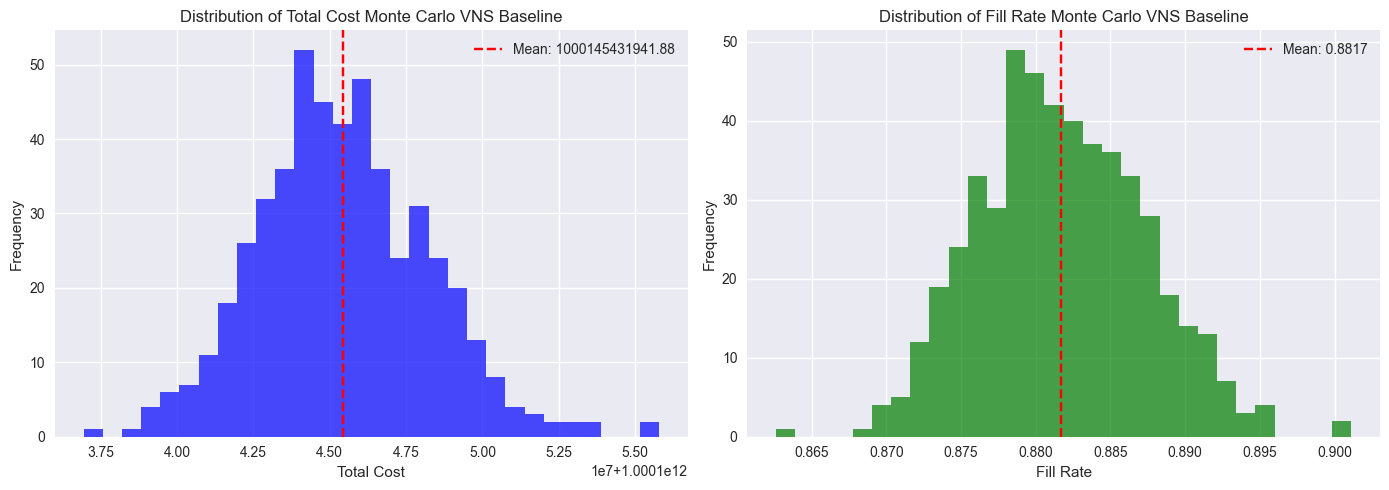

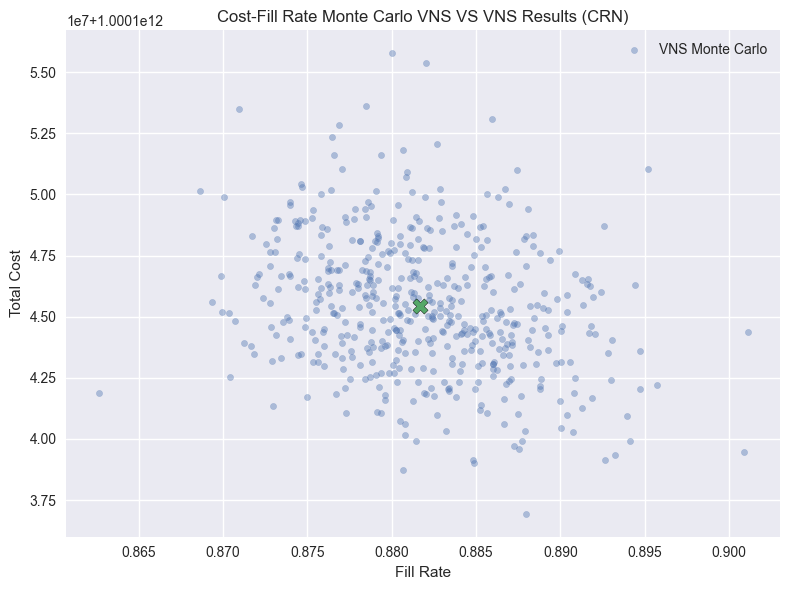

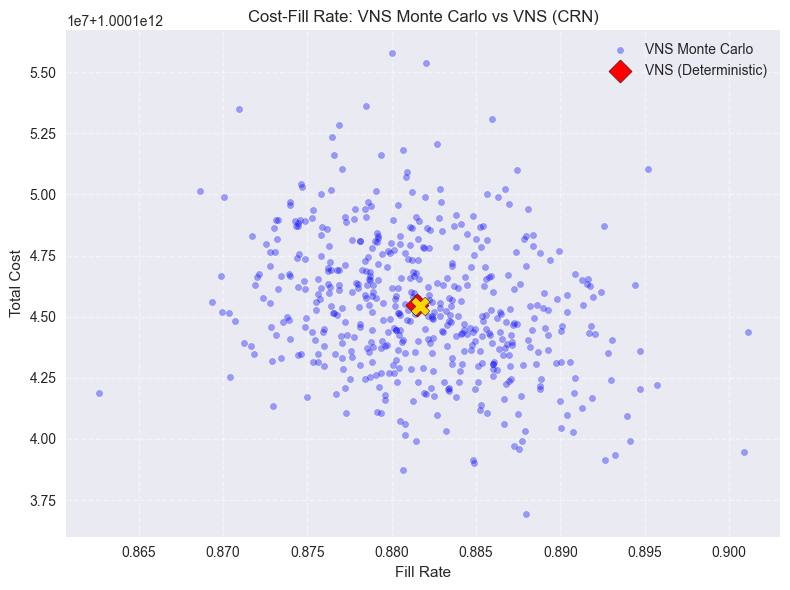

[OK] Clean CSV saved with single deterministic row.
[OK] VNS Monte Carlo Vs VNS paired saved to:
  - MONTE_CARLO_VNS_BASELINE_RUNS_4.csv
  - MONTE_CARLO_VNS_VS_VNS_PAIRED_COMPARISON_4.csv

=== SUMMARY COMPARISON ===
✅ MONTE_CARLO VNS has LOWER cost than VNS
✅ MONTE_CARLO VNS has HIGHER fill rate than VNS

Running Service Level Trade-off Analysis...
Running for service level 0.8...
Running for service level 0.82...
Running for service level 0.85...
Running for service level 0.88...
Running for service level 0.9...
Running for service level 0.92...
Running for service level 0.95...
Running for service level 0.98...
   svc_target     mean_cost      std_cost  mean_fill  std_fill
0        0.80  1.000145e+12  2.779875e+06   0.881696  0.005609
1        0.82  1.000145e+12  2.779875e+06   0.881696  0.005609
2        0.85  1.000145e+12  2.779875e+06   0.881696  0.005609
3        0.88  1.000147e+12  4.074879e+06   0.881696  0.005609
4        0.90  1.000164e+12  6.888714e+06   0.881696  0.005609
5

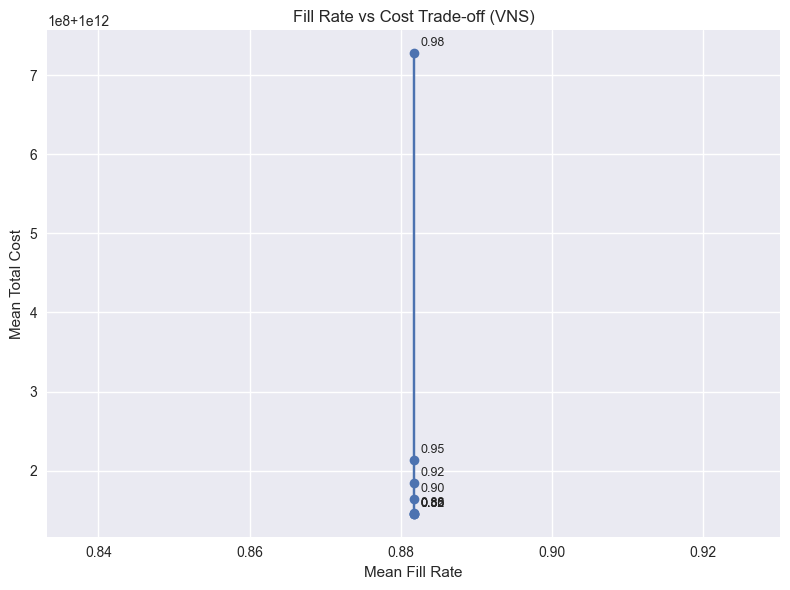

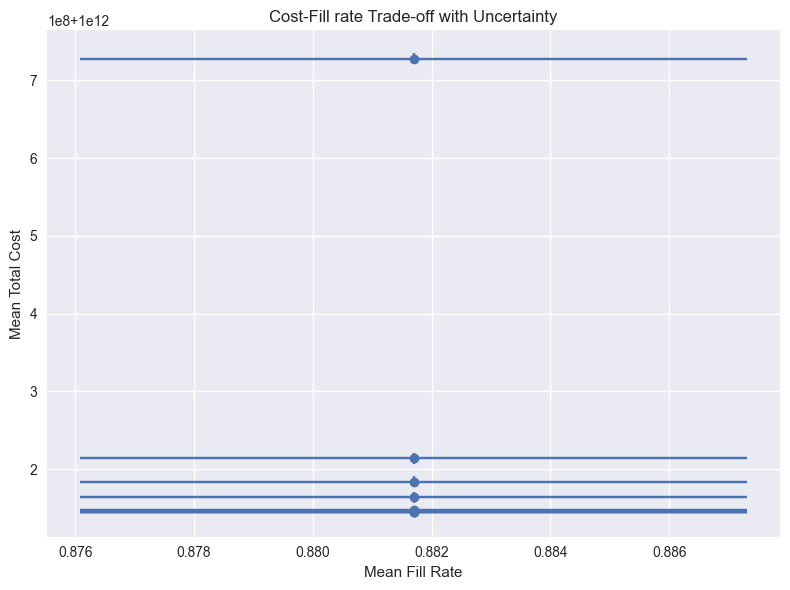

C:\Users\jsantoso\AppData\Local\Temp\ipykernel_50348\2883434904.py:638: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)


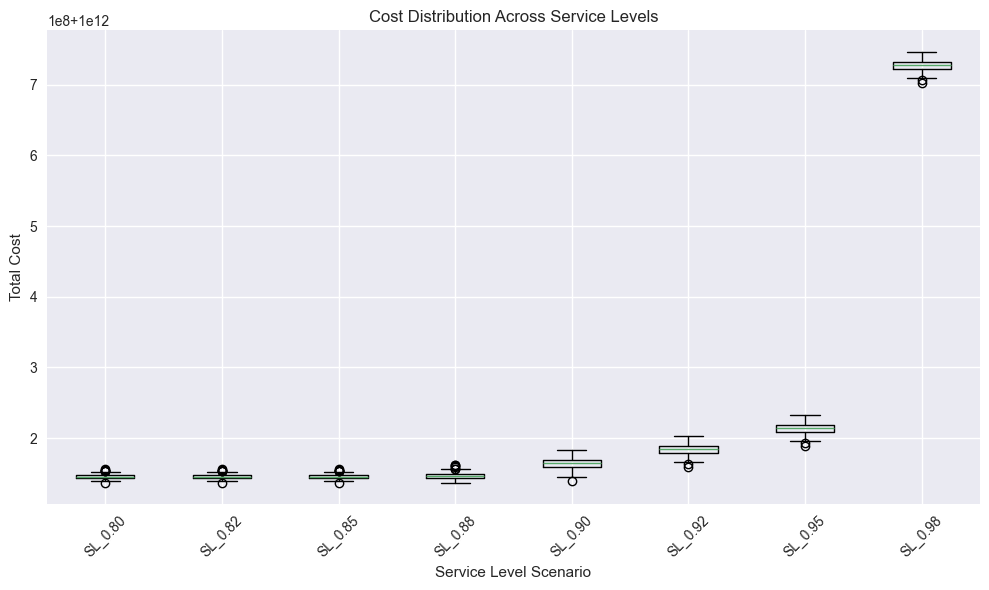

C:\Users\jsantoso\AppData\Local\Temp\ipykernel_50348\2883434904.py:656: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)


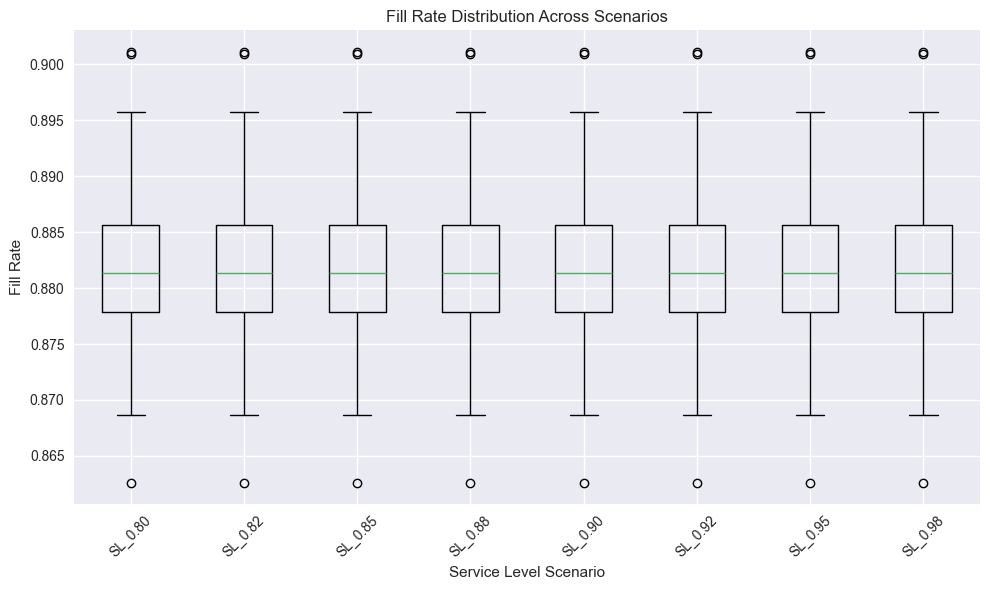

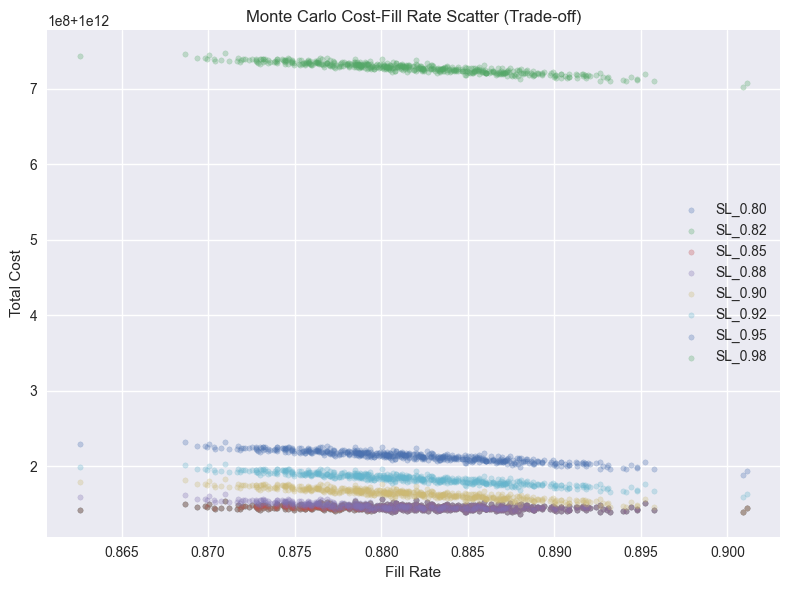

In [64]:
import scipy.stats as stats
from scipy.stats import bootstrap
from pathlib import Path

outdir = Path("output_vns")
outdir.mkdir(parents=True, exist_ok=True)

# Function for Monte Carlo simulation

def compute_mc_cost(Q, SS, D_cust_sim, D_dc_sim):
    holding = float(np.sum(h * (Q / 2.0 + SS)))

    ordering = 0.0
    order_miss_penalty = 0.0
    BIG_COST = 1e12
    for i in range(M):
        for j in range(N):
            Dij = D_dc_sim[i, j]
            Qij = max(Q[i, j], 0)
            if Dij <= 0:
                continue
            if Qij <= 0:
                if USE_MISSED_ORDER_PENALTY and Q_ub[i, j] > 0:  # match compute_cost: only feasible-to-order cells
                    order_miss_penalty += BIG_COST
            else:
                ordering += K[i, j] * (Dij / Qij)

    shortage_cost = 0.0
    shortage_volume = 0.0
    total_demand = 0.0
    for i in range(M):
        S_i = float(np.sum(Q[i] + SS[i]) + SOH_i[i])
        D_i_tot = float(np.sum(D_cust_sim[i]))
        if D_i_tot <= 0.0:
            continue
        B_i_tot = max(0.0, D_i_tot - S_i)
        shortage_volume += B_i_tot
        total_demand += D_i_tot
        if B_i_tot <= 1e-12:
            continue
        alloc = (D_cust_sim[i] / D_i_tot) * B_i_tot
        shortage_cost += float(np.sum(p_ik[i] * alloc))

    pen_budget = 0.0
    BIG_BUDGET_PENALTY = 1e12
    for i in range(M):
        total_inv_cost_i = float(np.sum((Q[i] + SS[i]) * K[i]))
        if total_inv_cost_i > I_i[i]:
            excess_budget = total_inv_cost_i - I_i[i]
            pen_budget += BIG_BUDGET_PENALTY * (excess_budget / max(I_i[i], 1.0))

    pen_cap = pen_qleqd = pen_ss = 0.0
    if USE_PENALTIES:
        cap_violation = np.maximum(Q + SS - C, 0)
        pen_cap = (cap_violation * PENALTY_CAPACITY).sum()

        # Q<=demand is a feasibility constraint on the FIXED plan -> evaluate against the
        # planned (deterministic) assigned demand, exactly like compute_cost. Re-checking it
        # against each random demand realization spuriously triggers the 1e12 wall and makes
        # the mean MC cost explode (you cannot un-order once Q is decided).
        q_leq_d_violation = np.maximum(Q - D_cust_assigned, 0)
        pen_qleqd = (q_leq_d_violation * PENALTY_Q_LEQ_D).sum()

        ss_deficit = np.maximum(SS_target - SS.sum(axis=1), 0.0)
        pen_ss = float(np.sum(ss_deficit) * PENALTY_SS_TARGET)

        #budget_violation = 0.0
        #K_bar_local = np.where(np.isnan(K).all(axis=1), 0.0, np.nanmean(K, axis=1))
        #for i in range(M):
        #    spend_i = float(np.sum(Q[i] + SS[i]) * max(K_bar_local[i], 0.0))
        #    over = max(0.0, spend_i - float(I_i[i]))
        #    budget_violation += over
        #pen_budget = budget_violation * PENALTY_BUDGET

    fill_rate = 1.0 - (shortage_volume / total_demand) if total_demand > 0 else 1.0
    pen_fill = PENALTY_FILL * max(0.0, TARGET_FILL - fill_rate)  # soft service penalty (matches compute_cost)
    total_basic = holding + ordering + shortage_cost
    total_penalty = order_miss_penalty + pen_cap + pen_qleqd + pen_ss + pen_budget + pen_fill
    total_cost = total_basic + total_penalty
    return total_cost, fill_rate


def monte_carlo_run(Q, SS, num_runs=500, seed=None):
    rng = np.random.default_rng(seed if seed is not None else RANDOM_SEED)
    costs = []
    fills = []
    for _ in range(num_runs):
        if USE_POISSON_SIGMA:
            D_sim = rng.poisson(mu_i)
        else:
            D_sim = rng.normal(mu_i, sigma_i)
        D_sim = np.maximum(D_sim, 0)

        factors = D_sim / np.maximum(mu_i, 1e-9)
        D_cust_sim = D_cust * factors.reshape(-1, 1)
        D_dc_sim = D_dc * factors.reshape(-1, 1)

        total_cost, fill_rate = compute_mc_cost(Q, SS, D_cust_sim, D_dc_sim)
        costs.append(total_cost)
        fills.append(fill_rate)

    return np.array(costs), np.array(fills)


def monte_carlo_run_candidates(candidates, num_runs=500, seed=None):
    rng = np.random.default_rng(seed if seed is not None else RANDOM_SEED)
    costs = {name: [] for name, _, _ in candidates}
    fills = {name: [] for name, _, _ in candidates}

    for _ in range(num_runs):
        if USE_POISSON_SIGMA:
            D_sim = rng.poisson(mu_i)
        else:
            D_sim = rng.normal(mu_i, sigma_i)
        D_sim = np.maximum(D_sim, 0)

        factors = D_sim / np.maximum(mu_i, 1e-9)
        D_cust_sim = D_cust * factors.reshape(-1, 1)
        D_dc_sim = D_dc * factors.reshape(-1, 1)

        for name, Q, SS in candidates:
            total_cost, fill_rate = compute_mc_cost(Q, SS, D_cust_sim, D_dc_sim)
            costs[name].append(total_cost)
            fills[name].append(fill_rate)

    return {name: np.array(values) for name, values in costs.items()}, {name: np.array(values) for name, values in fills.items()}


def paired_comparison(name_a, name_b, costs_dict, fills_dict):
    def stats_for(series_a, series_b):
        diff = series_a - series_b
        t_stat, t_p = stats.ttest_rel(series_a, series_b)
        w_stat, w_p = stats.wilcoxon(series_a, series_b, zero_method='wilcox', alternative='two-sided')
        binom_p = stats.binomtest(np.sum(diff > 0), n=len(diff), p=0.5).pvalue
        d = np.mean(diff) / np.std(diff, ddof=1) if np.std(diff, ddof=1) > 0 else np.nan
        rank_biserial = (np.sum(diff > 0) - np.sum(diff < 0)) / len(diff)
        return {
            'mean_diff': float(np.mean(diff)),
            'std_diff': float(np.std(diff, ddof=1)),
            'cohens_d': float(d),
            'rank_biserial': float(rank_biserial),
            'paired_t_stat': float(t_stat),
            'paired_t_pvalue': float(t_p),
            'wilcoxon_stat': float(w_stat),
            'wilcoxon_pvalue': float(w_p),
            'sign_test_pvalue': float(binom_p),
        }

    return {
        'cost_paired': stats_for(costs_dict[name_a], costs_dict[name_b]),
        'fill_paired': stats_for(fills_dict[name_a], fills_dict[name_b]),
    }


# Run Monte Carlo for baseline VNS and an initial heuristic
print("Running Monte Carlo for candidate solutions with common random numbers...")
Qb0, SSb0 = res['Q_best'], res['SS_best']

candidates = [
    ('VNS Monte Carlo', Qb0, SSb0),
    #('VNS', Qb0, SSb0),
    
]

costs_all, fill_rate_all = monte_carlo_run_candidates(candidates, num_runs=500, seed=RANDOM_SEED)

costs_base = costs_all['VNS Monte Carlo']
fills_base = fill_rate_all['VNS Monte Carlo']

mean_cost = np.mean(costs_base)
std_cost = np.std(costs_base)
mean_fill_rate = np.mean(fills_base)
std_fill_rate = np.std(fills_base)

print(f"Baseline VNS Monte Carlo Results:")
print(f"Total Cost: Mean = {mean_cost:.2f}, Std = {std_cost:.2f}")
print(f"Fill Rate: Mean = {mean_fill_rate:.4f}, Std = {std_fill_rate:.4f}")

# Bootstrap confidence intervals
def bootstrap_ci(data, stat_func, confidence=0.95, n_resamples=1000):
    res = bootstrap((data,), stat_func, confidence_level=confidence, n_resamples=n_resamples, method='percentile')
    return res.confidence_interval

ci_cost = bootstrap_ci(costs_base, np.mean)
ci_fill = bootstrap_ci(fills_base, np.mean)

ci_cost = bootstrap_ci(costs_base, np.mean)
ci_fill = bootstrap_ci(fills_base, np.mean)
print(f"95% CI for Mean Cost: [{ci_cost.low:.2f}, {ci_cost.high:.2f}]")
print(f"95% CI for Mean Fill Rate: [{ci_fill.low:.4f}, {ci_fill.high:.4f}]")

# Paired tests and nonparametric alternatives
#VNS baseline breakdown (approximate from best solution)
det_cost, det_fill = bd['total'], bd['fill_rate']  # approximate

print(f"VNS Results:")
print(f"Total Cost: Best = {det_cost:.2f}")
print(f"Fill Rate: Best = {det_fill:.4f}")

cost_det_vec = np.full_like(costs_base, det_cost, dtype=float)
fill_det_vec = np.full_like(fills_base, det_fill, dtype=float)

comparison = paired_comparison(
    'VNS Monte Carlo', 'VNS',
    {
        'VNS Monte Carlo': costs_all['VNS Monte Carlo'],
        'VNS': cost_det_vec
    },
    {
        'VNS Monte Carlo': fill_rate_all['VNS Monte Carlo'],
        'VNS': fill_det_vec
    }
)

#comparison = paired_comparison('VNS Monte Carlo', 'VNS', costs_all, services_all)
print('\nPaired comparison: VNS Monte Carlo vs VNS deterministic')
for metric in ['cost_paired', 'fill_paired']:
    stats_row = comparison[metric]
    print(f"\n{metric.capitalize()} results:")
    print(f"  - Mean diff = {stats_row['mean_diff']:.2f}")
    print(f"  - Cohen's d = {stats_row['cohens_d']:.4f}")
    print(f"  - Rank biserial = {stats_row['rank_biserial']:.4f}")
    print(f"  - Paired t-test: t = {stats_row['paired_t_stat']:.2f}, p = {stats_row['paired_t_pvalue']:.4f}")
    print(f"  - Wilcoxon signed-rank: W = {stats_row['wilcoxon_stat']:.2f}, p = {stats_row['wilcoxon_pvalue']:.4f}")
    print(f"  - Sign test (binomial): p = {stats_row['sign_test_pvalue']:.4f}")

# Plot distributions and cost-fill_rate scatter
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(costs_base, bins=30, alpha=0.7, color='blue')
ax1.axvline(mean_cost, color='red', linestyle='--', label=f'Mean: {mean_cost:.2f}')
ax1.set_title('Distribution of Total Cost Monte Carlo VNS Baseline')
ax1.set_xlabel('Total Cost')
ax1.set_ylabel('Frequency')
ax1.legend()

ax2.hist(fills_base, bins=30, alpha=0.7, color='green')
ax2.axvline(mean_fill_rate, color='red', linestyle='--', label=f'Mean: {mean_fill_rate:.4f}')
ax2.set_title('Distribution of Fill Rate Monte Carlo VNS Baseline')
ax2.set_xlabel('Fill Rate')
ax2.set_ylabel('Frequency')
ax2.legend()

plt.tight_layout()
plt.savefig(outdir / 'Monte_Carlo_VNS_Baseline_Distributions_6.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for name in costs_all:
    ax.scatter(fill_rate_all[name], costs_all[name], s=20, alpha=0.4, label=name)
    ax.scatter(np.mean(fill_rate_all[name]), np.mean(costs_all[name]), marker='X', s=120, edgecolors='black')
ax.set_xlabel('Fill Rate')
ax.set_ylabel('Total Cost')
ax.set_title('Cost-Fill Rate Monte Carlo VNS VS VNS Results (CRN)')
ax.legend()
plt.tight_layout()
plt.savefig(outdir / 'Monte_Carlo_VNS_Cost_Fill_Rate_Comparison4.png', dpi=150)
plt.show()


# Combine both stochastic and deterministic results
fig, ax = plt.subplots(figsize=(8, 6))

costs_plot = {
    'VNS Monte Carlo': costs_all['VNS Monte Carlo'],
    'VNS': cost_det_vec
}
fills_plot = {
    'VNS Monte Carlo': fill_rate_all['VNS Monte Carlo'],
    'VNS': fill_det_vec
}

for name in costs_plot:
    
    if name == 'VNS':
        # ✅ Deterministic as SINGLE point (cleaner & correct)
        ax.scatter(
            np.mean(fills_plot[name]),
            np.mean(costs_plot[name]),
            s=140,
            color='red',
            marker='D',
            edgecolors='black',
            label=f"{name} (Deterministic)",
            zorder=6
        )
    else:
       # ✅ Monte Carlo cloud
        ax.scatter(
            fills_plot[name],
            costs_plot[name],
            s=20,
            alpha=0.35,
            color='blue',
            label=name
        )
        
        # ✅ Mean marker for Monte Carlo
        ax.scatter(
            np.mean(fills_plot[name]),
            np.mean(costs_plot[name]),
            marker='X',
            s=180,
            color='gold',
            edgecolors='black',
            zorder=7
        )

# Labels and title
ax.set_xlabel('Fill Rate')
ax.set_ylabel('Total Cost')
ax.set_title('Cost-Fill Rate: VNS Monte Carlo vs VNS (CRN)', fontsize=12)

# ✅ Remove duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='best')

# ✅ Grid for readability
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(outdir / 'Monte_Carlo_VNS_VS-VNS_Cost_Fill_Rate_Comparison_4.png', dpi=150)
plt.show()


candidate_runs = []

# ==================================
# ✅ 1. SAVE MONTE CARLO RUNS
# ==================================
num_runs = len(next(iter(costs_all.values())))  # robust way

for run_id in range(1, num_runs + 1):
    for name in costs_all:
        if 'Monte Carlo' in name:   # ✅ ONLY MC
            candidate_runs.append({
                'run_id': run_id,
                'strategy': name,
                'type': 'MC',                     # ✅ ADD TYPE (IMPORTANT)
                'total_cost': float(costs_all[name][run_id - 1]),
                'fill_rate': float(fill_rate_all[name][run_id - 1])
            })

# ==================================
# ✅ 2. SAVE DETERMINISTIC (ONLY ONCE)
# ==================================
candidate_runs.append({
    'run_id': 0,
    'strategy': 'VNS',
    'type': 'Deterministic',        # ✅ CLEAR LABEL
    'total_cost': float(det_cost),
    'fill_rate': float(det_fill)
})

# ==================================
# ✅ 3. CREATE DATAFRAME
# ==================================
candidate_runs_df = pd.DataFrame(candidate_runs)

# ==================================
# ✅ 4. SAVE CSV
# ==================================
candidate_runs_df.to_csv(
    outdir / 'MONTE_CARLO_VNS_CANDIDATE_RUNS_4_CLEAN.csv',
    index=False
)

print('[OK] Clean CSV saved with single deterministic row.')

pairwise_runs_df = pd.DataFrame(candidate_runs)
pairwise_runs_df.to_csv(outdir / 'MONTE_CARLO_VNS_CANDIDATE_RUNS_4.csv', index=False)

comparison_df = pd.DataFrame([
    {
        'metric': 'cost_paired',
        'mean_diff': comparison['cost_paired']['mean_diff'],
        'std_diff': comparison['cost_paired']['std_diff'],
        'cohens_d': comparison['cost_paired']['cohens_d'],
        'rank_biserial': comparison['cost_paired']['rank_biserial'],
        'paired_t_stat': comparison['cost_paired']['paired_t_stat'],
        'paired_t_pvalue': comparison['cost_paired']['paired_t_pvalue'],
        'wilcoxon_stat': comparison['cost_paired']['wilcoxon_stat'],
        'wilcoxon_pvalue': comparison['cost_paired']['wilcoxon_pvalue'],
        'sign_test_pvalue': comparison['cost_paired']['sign_test_pvalue'],
    },
    {
        'metric': 'fill_paired',
        'mean_diff': comparison['fill_paired']['mean_diff'],
        'std_diff': comparison['fill_paired']['std_diff'],
        'cohens_d': comparison['fill_paired']['cohens_d'],
        'rank_biserial': comparison['fill_paired']['rank_biserial'],
        'paired_t_stat': comparison['fill_paired']['paired_t_stat'],
        'paired_t_pvalue': comparison['fill_paired']['paired_t_pvalue'],
        'wilcoxon_stat': comparison['fill_paired']['wilcoxon_stat'],
        'wilcoxon_pvalue': comparison['fill_paired']['wilcoxon_pvalue'],
        'sign_test_pvalue': comparison['fill_paired']['sign_test_pvalue'],
    }
])

comparison_df.to_csv(outdir / 'MONTE_CARLO_VNS_Vs_VNS_PAIRED_COMPARISON_4.csv', index=False)

print(f'[OK] VNS Monte Carlo Vs VNS paired saved to:')
print(f'  - MONTE_CARLO_VNS_BASELINE_RUNS_4.csv')
print(f'  - MONTE_CARLO_VNS_VS_VNS_PAIRED_COMPARISON_4.csv')


comparison_df.set_index('metric', inplace=True)

print('\n=== SUMMARY COMPARISON ===')
if comparison_df.loc['cost_paired','mean_diff'] < 0:
    print('✅ MONTE_CARLO VNS has LOWER cost than VNS')
else:
    print('⚠️ MONTE_CARLO VNS has HIGHER cost than VNS')

if comparison_df.loc['fill_paired','mean_diff'] > 0:
    print('✅ MONTE_CARLO VNS has HIGHER fill rate than VNS')
else:
    print('⚠️ MONTE_CARLO VNS has LOWER fill rate than VNS')


# ============================================
# ✅ TRADE-OFF: SERVICE LEVEL SCENARIO ANALYSIS
# ============================================

def generate_service_scenarios(Q_base, SS_base, scale_grid):
    scenarios = []
    for alpha in scale_grid:
        SS_new = SS_base * alpha
        name = f"SL_scale_{alpha:.2f}"
        scenarios.append((name, Q_base, SS_new))
    return scenarios


def monte_carlo_tradeoff(Q_base, SS_base, scale_grid, num_runs=500, seed=None):
    scenarios = generate_service_scenarios(Q_base, SS_base, scale_grid)

    # Run MC using SAME random numbers (CRN)
    costs_dict, fills_dict = monte_carlo_run_candidates(
        scenarios, num_runs=num_runs, seed=seed
    )

    # Aggregate results
    rows = []
    for name in costs_dict:
        rows.append({
            'scenario': name,
            'scale': float(name.split('_')[-1]),
            'mean_cost': float(np.mean(costs_dict[name])),
            'std_cost': float(np.std(costs_dict[name])),
            'mean_fill_rate': float(np.mean(fills_dict[name])),
            'std_fill_rate': float(np.std(fills_dict[name]))
        })

    df = pd.DataFrame(rows)
    df.sort_values('mean_fill', inplace=True)

    return df, costs_dict, fills_dict


# ============================================
# ✅ RUN TRADE-OFF ANALYSIS
# ============================================

print("\nRunning Service Level Trade-off Analysis...")

## Grid of service level multipliers
#scale_grid = np.linspace(0.6, 1.4, 12)   # adjust resolution

#tradeoff_df, costs_trade, services_trade = monte_carlo_tradeoff(
#    Qb0, SSb0,
#    scale_grid=scale_grid,
#    num_runs=500,
#    seed=RANDOM_SEED
#)

#print(tradeoff_df.head())

# ============================================
# ✅ SERVICE-LEVEL-BASED TRADE-OFF ANALYSIS
# ============================================

def set_env(svc=0.90, seed=None):
    global Z_SERVICE, SS_target, Q0, SS0, SS_lb, SS_ub, TARGET_FILL
    from scipy.stats import norm

    Z_SERVICE = norm.ppf(svc)
    #SS_target = Z_SERVICE * np.sqrt(np.maximum(L_i, 0.0) * np.maximum(sigma_i, 0.0))
    SS_target = Z_SERVICE * sigma_i * np.sqrt(np.maximum(L_i, 0.0))

    D_prop = D_dc / np.maximum(D_dc.sum(axis=1, keepdims=True), 1e-9)
    SS_prop = np.ones_like(D_prop) / N

    Q0 = np.floor((EOQ_i.reshape(-1, 1) * D_prop)).astype(int)
    SS0 = np.ceil((SS_target.reshape(-1, 1) * SS_prop)).astype(int)

    SS_ub = np.floor(C).astype(int)
    # Align trade-off sweep with the baseline fill-rate targeting: set the SS floor via the
    # budget/capacity-aware coverage allocation for THIS service level, and steer pen_fill to it.
    TARGET_FILL = svc
    SS_lb = np.minimum(_coverage_ss_floor(svc), SS_ub).astype(int)
    SS0 = np.clip(SS0, SS_lb, SS_ub)

    if seed is None:
        seed = RANDOM_SEED
    np.random.seed(seed)

svc_levels = [0.80, 0.82, 0.85, 0.88, 0.90, 0.92, 0.95, 0.98] #[0.90, 0.92, 0.95, 0.97, 0.98]

trade_off_results = []

# Storage (same structure as before → compatible with boxplot code)
costs_trade = {}
fills_trade = {}

for svc in svc_levels:
    print(f"Running for service level {svc}...")

    # ✅ Set target service level
    set_env(svc=svc)

    # ✅ Reproducibility
    if 'BASE' in globals() and isinstance(BASE, dict) and 'seed' in BASE:
        np.random.seed(BASE['seed'])
    else:
        np.random.seed(RANDOM_SEED)

    # ✅ Re-optimization
    if 'run_ga_vns_hybrid' in globals():
        res = run_ga_vns_hybrid(pop_size=POP_SIZE, generations=GENERATIONS)
    
    elif 'vns_multistart' in globals() and 'run_ga' not in globals():
        res = run_vns_full()

    Q, SS = res['Q_best'], res['SS_best']

    # ✅ Monte Carlo evaluation
    costs, fills = monte_carlo_run(Q, SS, num_runs=500)

    # ✅ Store distributions (important for boxplot)
    scenario_name = f"SL_{svc:.2f}"
    costs_trade[scenario_name] = costs
    fills_trade[scenario_name] = fills

    # ✅ Aggregate metrics
    mean_c = np.mean(costs)
    std_c = np.std(costs)
    mean_f = np.mean(fills)
    std_f = np.std(fills)

    trade_off_results.append({
        'svc_target': svc,
        'mean_cost': mean_c,
        'std_cost': std_c,
        'mean_fill': mean_f,
        'std_fill': std_f
    })

# ============================================
# ✅ DATAFRAME (FOR CSV + ANALYSIS)
# ============================================

tradeoff_df = pd.DataFrame(trade_off_results)
tradeoff_df.sort_values('mean_fill', inplace=True)

print(tradeoff_df)

tradeoff_df.to_csv(
    outdir / 'TRADEOFF_SERVICE_TARGET_RESULTS_VNS_4.csv',
    index=False
)

print("[OK] Service-level trade-off results saved")

#1. Trade-off Curve (MAIN import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

# Sort ensures smooth curve
df_plot = tradeoff_df.sort_values('mean_fill')

ax.plot(
    df_plot['mean_fill'],
    df_plot['mean_cost'],
    marker='o',
    linestyle='-'
)

# Annotate service targets
for _, row in df_plot.iterrows():
    ax.annotate(
        f"{row['svc_target']:.2f}",
        (row['mean_fill'], row['mean_cost']),
        textcoords="offset points",
        xytext=(5,5),
        fontsize=9
    )

ax.set_xlabel('Mean Fill Rate')
ax.set_ylabel('Mean Total Cost')
ax.set_title('Fill Rate vs Cost Trade-off (VNS)')
ax.grid(True)

plt.tight_layout()
plt.savefig(outdir / 'TRADEOFF_COST_FILL_RATE_CURVE_VNS_4.png', dpi=150)
plt.show()

#2. Error Bar Plot (adds uncertainty)
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(
    tradeoff_df['mean_fill'],
    tradeoff_df['mean_cost'],
    xerr=tradeoff_df['std_fill'],
    yerr=tradeoff_df['std_cost'],
    fmt='o',
    capsize=5
)

ax.set_xlabel('Mean Fill Rate')
ax.set_ylabel('Mean Total Cost')
ax.set_title('Cost-Fill rate Trade-off with Uncertainty')
ax.grid(True)

plt.tight_layout()
plt.savefig(outdir / 'TRADEOFF_WITH_ERROR_BARS_VNS_4.png', dpi=150)
plt.show()

#3. Boxplots
#Shows full distributions per service level
#Cost distribution:

fig, ax = plt.subplots(figsize=(10, 6))

labels = list(costs_trade.keys())
data = [costs_trade[k] for k in labels]

ax.boxplot(data, labels=labels)

ax.set_xlabel('Service Level Scenario')
ax.set_ylabel('Total Cost')
ax.set_title('Cost Distribution Across Service Levels')
ax.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(outdir / 'TRADEOFF_COST_BOXPLOT_VNS_4.png', dpi=150)
plt.show()

#Service distribution:
fig, ax = plt.subplots(figsize=(10, 6))

labels = list(fills_trade.keys())
data = [fills_trade[k] for k in labels]

ax.boxplot(data, labels=labels)

ax.set_xlabel('Service Level Scenario')
ax.set_ylabel('Fill Rate')
ax.set_title('Fill Rate Distribution Across Scenarios')
ax.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(outdir / 'TRADEOFF_FILL_RATE_BOXPLOT_VNS_4.png', dpi=150)
plt.show()

#4. Scatter Cloud (optional but insightful)
fig, ax = plt.subplots(figsize=(8, 6))

for name in costs_trade:
    ax.scatter(
        fills_trade[name],
        costs_trade[name],
        alpha=0.3,
        s=15,
        label=name
    )

ax.set_xlabel('Fill Rate')
ax.set_ylabel('Total Cost')
ax.set_title('Monte Carlo Cost-Fill Rate Scatter (Trade-off)')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig(outdir / 'TRADEOFF_SCATTER_VNS_4.png', dpi=150)
plt.show()

